In [1]:
import pandas as pd
import numpy as np
import yfinance as yf

# Day 1 - Data Stats

## 1.1. Data import

In [2]:
# TSM (Tech), JPM (Finanse), XOM (Energia), EEM (Rynki Wschodzące), SPY (Benchmark)
tickers = ['TSM', 'AAPL', 'JPM', 'XOM', 'EEM', 'SPY', 'GLD', 'BND']

start_date = '2019-01-01'
end_date = '2024-01-01'

# z data loader
data = pd.read_csv("data/prices.csv", index_col="Date", parse_dates=True)


In [3]:
data.head()

,AAPL,BND,EEM,GLD,JPM,SPY,TSM,XOM
Date,,,,,,,,
2019-01-02,37.503735,64.321198,33.319088,121.330002,81.250206,224.995316,31.237253,50.001842
2019-01-03,33.768074,64.572441,32.714996,122.430000,80.095505,219.626312,29.389702,49.234142
2019-01-04,35.209614,64.377930,33.770046,121.440002,83.048256,226.982864,29.911455,51.049374
2019-01-07,35.131245,64.280670,33.846619,121.860001,83.105995,228.772552,30.133850,51.314842
2019-01-08,35.800957,64.199623,33.974255,121.529999,82.949287,230.921951,29.885803,51.687935


In [4]:
data.shape

(1258, 8)

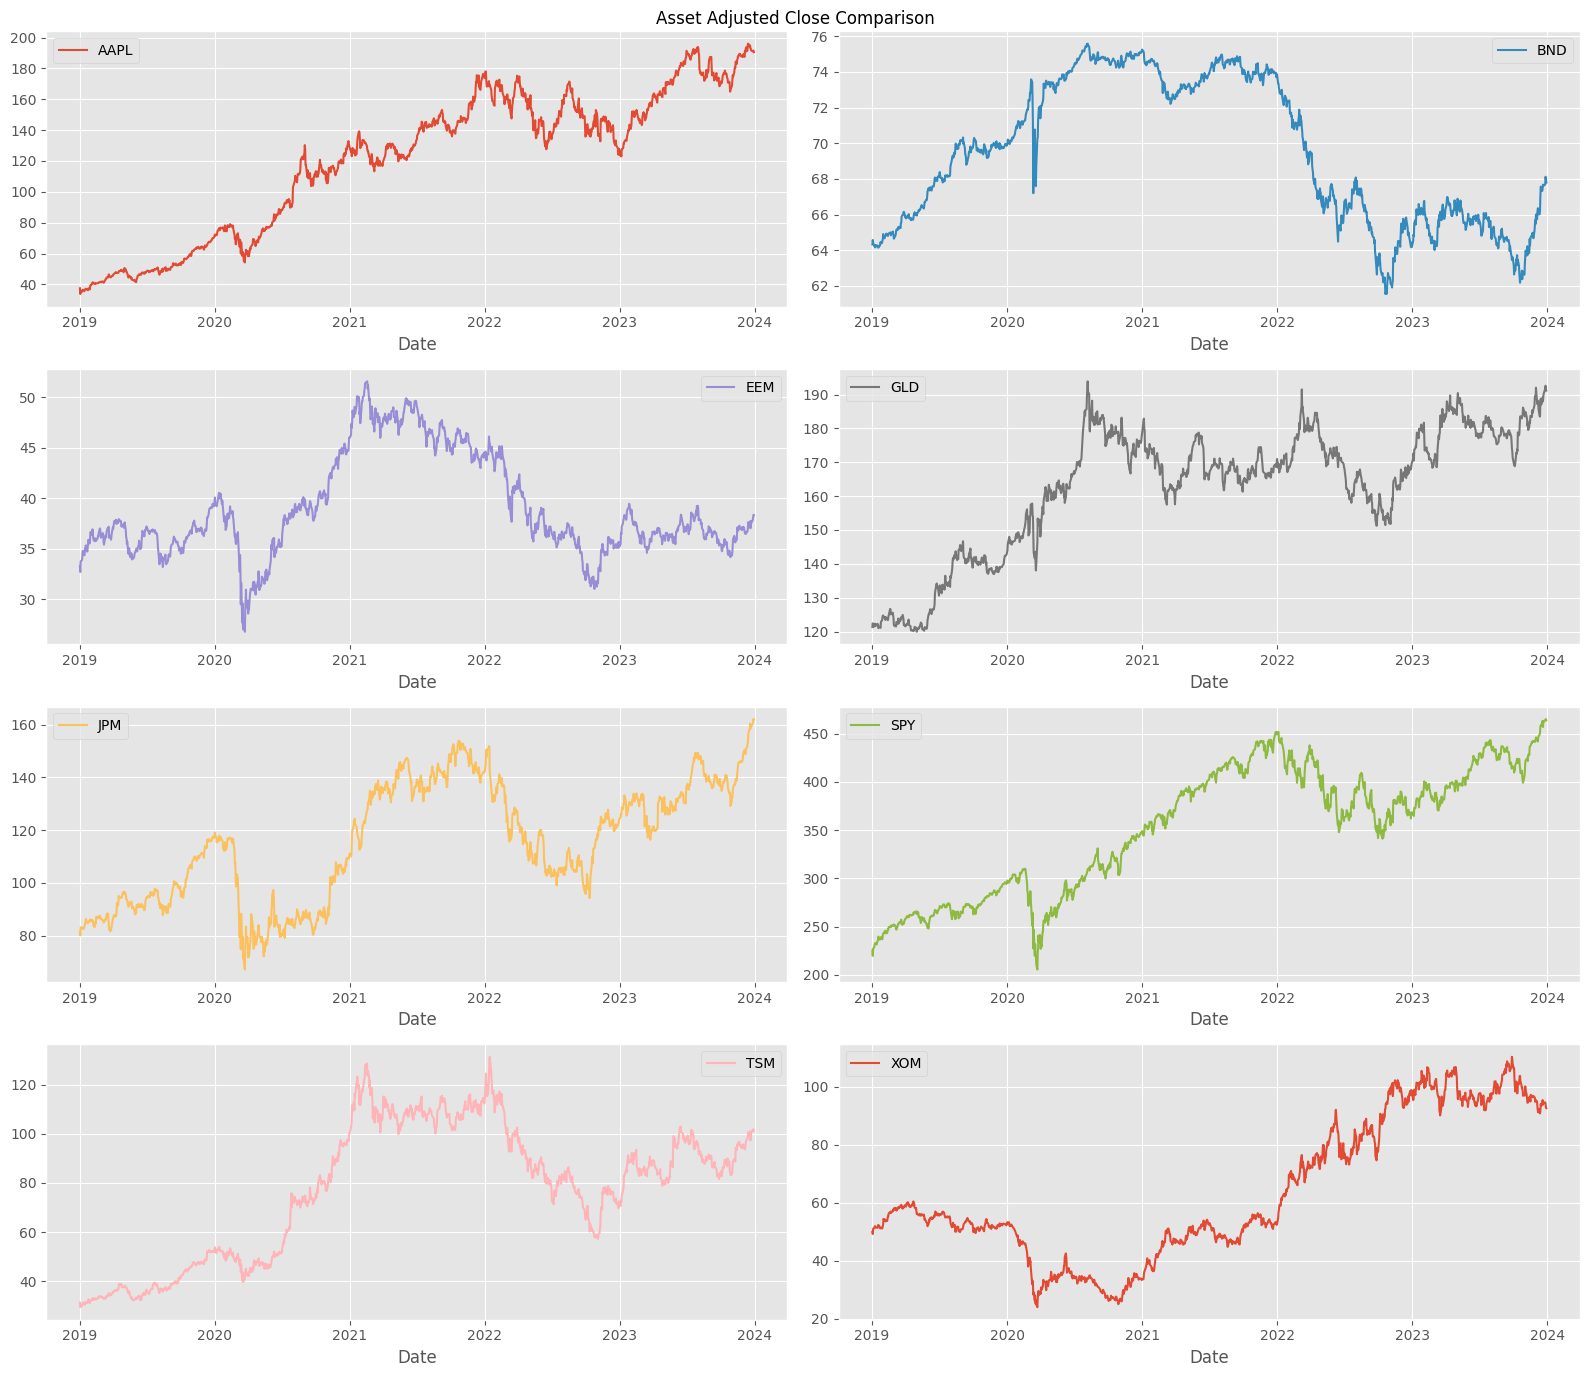

In [5]:
import matplotlib.pyplot as plt

plt.style.use('ggplot')

axes = data.plot(
    subplots=True, 
    layout=(4, 2),       
    figsize=(16, 14),  
    sharex=False,    
    grid=True,             
    linewidth=1.5,
    title="Asset Adjusted Close Comparison",
)
plt.tight_layout()      


## 1.3. Calculating Daily Log Returns

In [6]:
data.head()

,AAPL,BND,EEM,GLD,JPM,SPY,TSM,XOM
Date,,,,,,,,
2019-01-02,37.503735,64.321198,33.319088,121.330002,81.250206,224.995316,31.237253,50.001842
2019-01-03,33.768074,64.572441,32.714996,122.430000,80.095505,219.626312,29.389702,49.234142
2019-01-04,35.209614,64.377930,33.770046,121.440002,83.048256,226.982864,29.911455,51.049374
2019-01-07,35.131245,64.280670,33.846619,121.860001,83.105995,228.772552,30.133850,51.314842
2019-01-08,35.800957,64.199623,33.974255,121.529999,82.949287,230.921951,29.885803,51.687935


In [7]:
log_returns = np.log(data/data.shift(1))
log_returns = log_returns.dropna()  #drops first row
print(log_returns.shape)
log_returns.head()

(1257, 8)


,AAPL,BND,EEM,GLD,JPM,SPY,TSM,XOM
Date,,,,,,,,
2019-01-03,-0.104925,0.003898,-0.018297,0.009025,-0.014314,-0.024152,-0.060967,-0.015473
2019-01-04,0.041803,-0.003017,0.031741,-0.008119,0.036202,0.032947,0.017597,0.036206
2019-01-07,-0.002228,-0.001512,0.002265,0.003453,0.000695,0.007854,0.007408,0.005187
2019-01-08,0.018884,-0.001262,0.003764,-0.002712,-0.001887,0.009351,-0.008266,0.007244
2019-01-09,0.016839,0.001388,0.017624,0.006398,-0.001692,0.004663,0.018994,0.005261


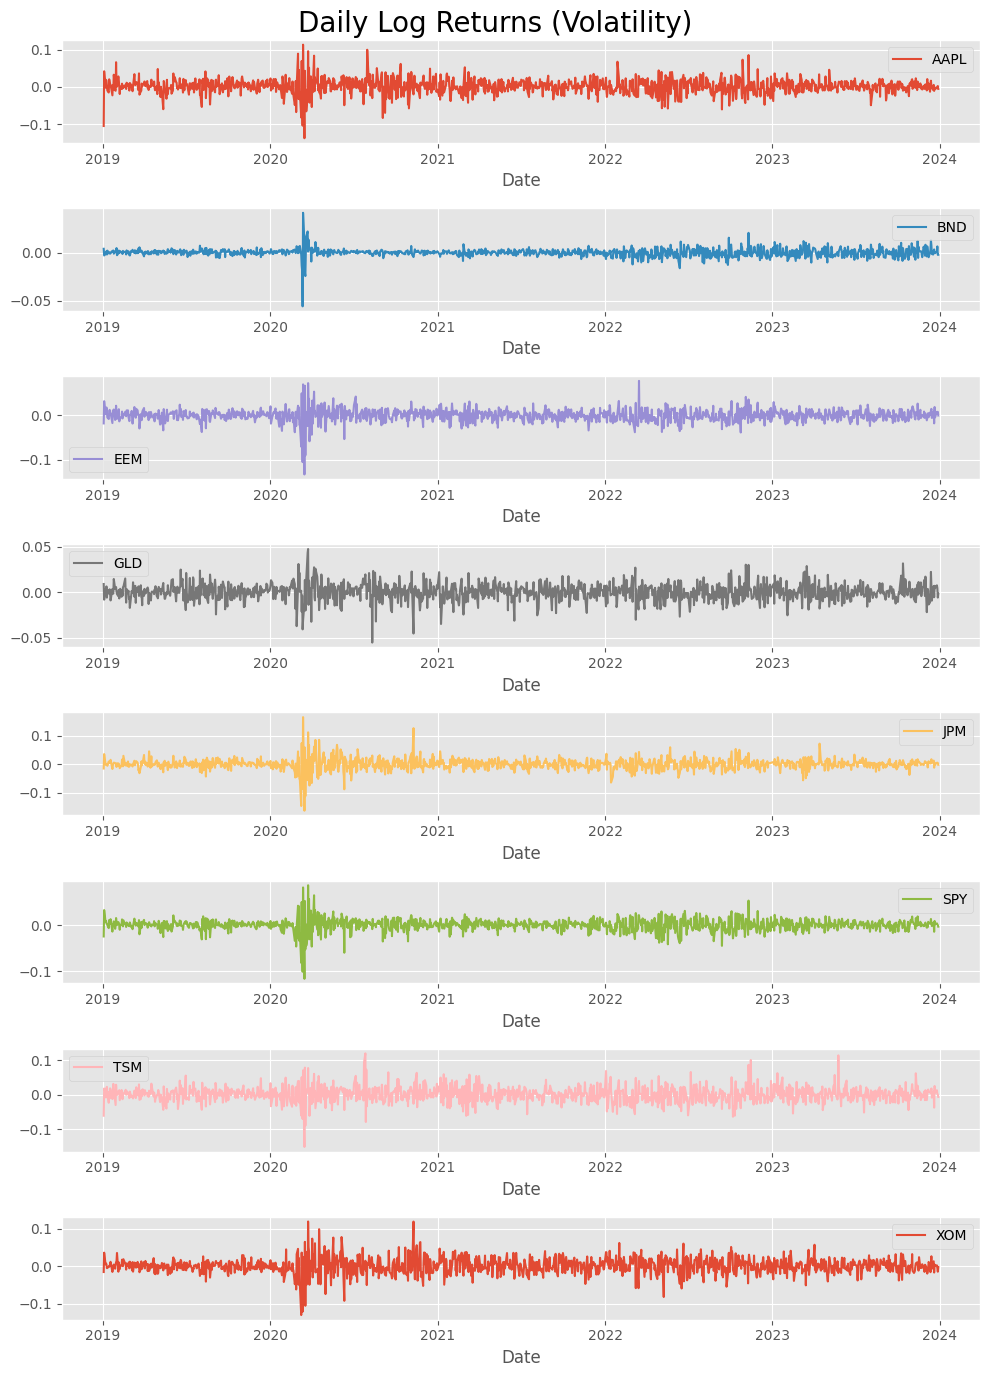

In [8]:
log_returns.plot(figsize=(10,14), subplots=True, sharex=False)
plt.suptitle('Daily Log Returns (Volatility)', fontsize=20)

plt.tight_layout()


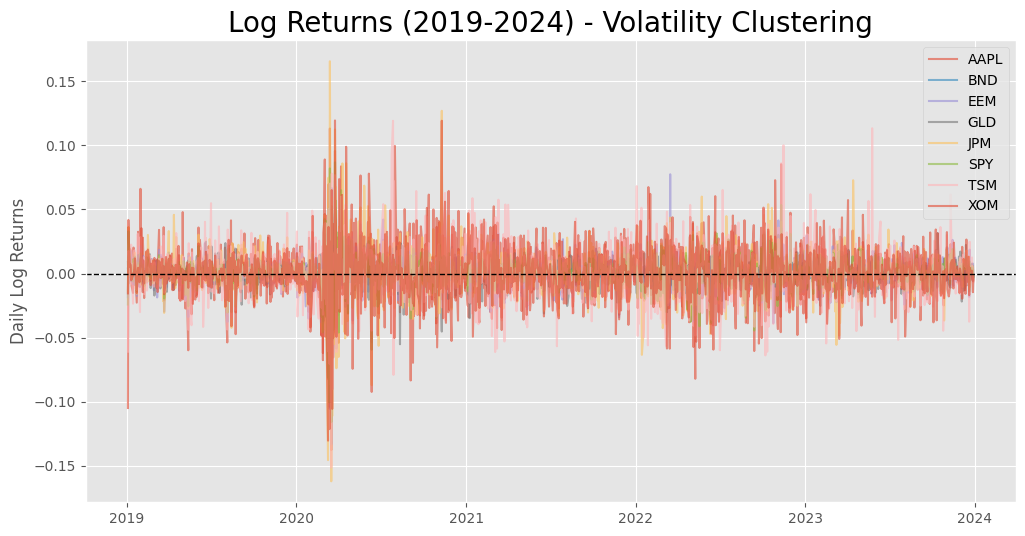

In [9]:
import matplotlib.pyplot as plt

# --- 1. Szereg czasowy (Wizualizacja Volatility Clustering) ---
# Powinieneś zauważyć, że w okresach kryzysów (np. marzec 2020) 
# wykres "szaleje" (duże odchylenia od zera) dla wszystkich aktywów naraz.
plt.figure(figsize=(12, 6))
plt.plot(log_returns, alpha=0.6)
plt.axhline(0, color='black', linestyle='--', linewidth=1)
plt.title('Log Returns (2019-2024) - Volatility Clustering', fontsize=20)
plt.ylabel('Daily Log Returns')
plt.legend(log_returns.columns)
plt.show()


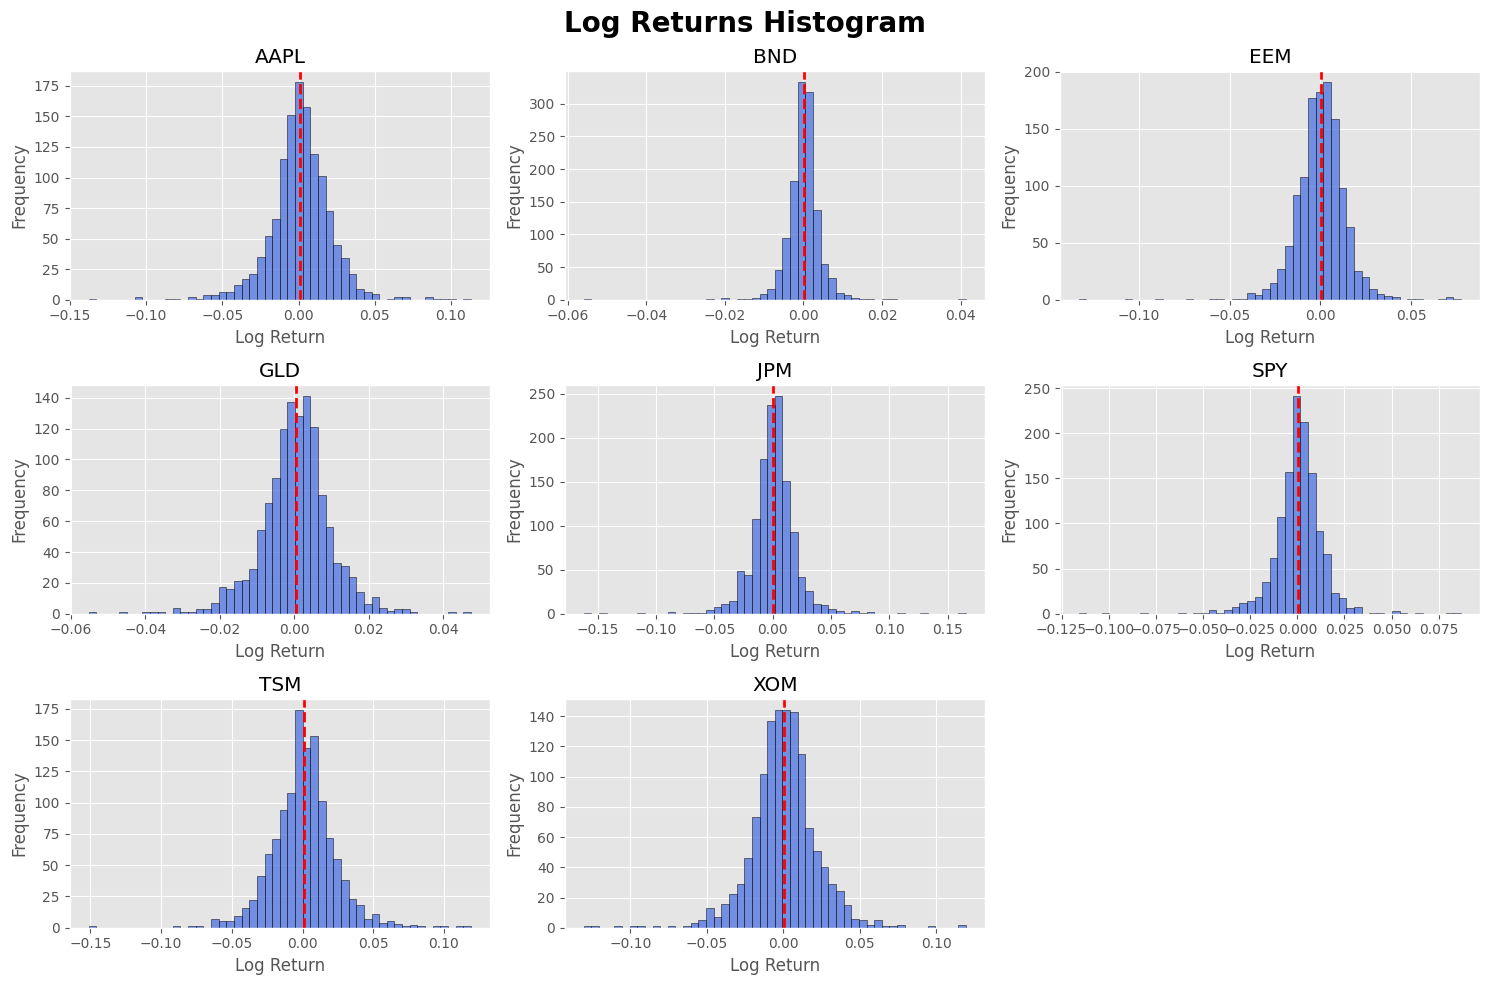

In [10]:
import matplotlib.pyplot as plt

# 1. Generate plots
axes = log_returns.hist(bins=50, figsize=(15, 10), color='royalblue', edgecolor='black', alpha=0.7)

# 2. Iterate through axes
for ax in axes.flatten():
    ticker = ax.get_title()
    
    # Check if the title corresponds to a valid column
    if ticker in log_returns.columns:
        mean_val = log_returns[ticker].mean()
        ax.axvline(mean_val, color='red', linestyle='dashed', linewidth=2)
        # Optional: Add a label for clarity
        ax.set_xlabel('Log Return')
        ax.set_ylabel('Frequency')
    else:
        # Hide empty subplots for a cleaner look
        ax.set_axis_off()

plt.suptitle('Log Returns Histogram', fontsize=20, fontweight='bold')
plt.tight_layout()
plt.show()

## 1.4. Covariance and the Covariance Martix

In [11]:
daily_covar_martix = log_returns.cov()
daily_covar_martix

,AAPL,BND,EEM,GLD,JPM,SPY,TSM,XOM
AAPL,0.000413,0.000012,0.000178,0.000016,0.000187,0.000217,0.000260,0.000142
BND,0.000012,0.000018,0.000010,0.000015,0.000003,0.000011,0.000010,-0.000003
EEM,0.000178,0.000010,0.000201,0.000025,0.000174,0.000147,0.000219,0.000150
GLD,0.000016,0.000015,0.000025,0.000089,-0.000010,0.000013,0.000025,0.000012
JPM,0.000187,0.000003,0.000174,-0.000010,0.000402,0.000196,0.000192,0.000257
SPY,0.000217,0.000011,0.000147,0.000013,0.000196,0.000176,0.000189,0.000160
TSM,0.000260,0.000010,0.000219,0.000025,0.000192,0.000189,0.000501,0.000152
XOM,0.000142,-0.000003,0.000150,0.000012,0.000257,0.000160,0.000152,0.000466


In [12]:
#the main diagonal of this is the annualized VARIANCE (covariance with itself)
trading_days = 252

annualized_covar_matrix = daily_covar_martix * 252
annualized_covar_matrix

,AAPL,BND,EEM,GLD,JPM,SPY,TSM,XOM
AAPL,0.104004,0.003023,0.044897,0.004116,0.047067,0.054788,0.065439,0.035702
BND,0.003023,0.004583,0.002593,0.003841,0.000653,0.002653,0.002432,-0.000732
EEM,0.044897,0.002593,0.050666,0.006315,0.043811,0.036959,0.055228,0.037788
GLD,0.004116,0.003841,0.006315,0.022351,-0.002446,0.003392,0.006189,0.003077
JPM,0.047067,0.000653,0.043811,-0.002446,0.101373,0.049386,0.048265,0.064863
SPY,0.054788,0.002653,0.036959,0.003392,0.049386,0.044449,0.047560,0.040244
TSM,0.065439,0.002432,0.055228,0.006189,0.048265,0.047560,0.126200,0.038406
XOM,0.035702,-0.000732,0.037788,0.003077,0.064863,0.040244,0.038406,0.117536


In [13]:
# log annualized returns (average) 
log_annualized_returns_average_asset = log_returns.mean() * trading_days
log_annualized_returns_average_asset

AAPL    0.325871
BND     0.010549
EEM     0.028170
GLD     0.091147
JPM     0.138290
SPY     0.145039
TSM     0.235629
XOM     0.123630
dtype: float64

In [14]:
#converted to actual annual returns (discrete)
# This creates a new Series of formatted strings
annualized_returns_average_asset = ((np.exp(log_annualized_returns_average_asset) - 1) * 100).map("{:.2f}%".format)
annualized_returns_average_asset


AAPL    38.52%
BND      1.06%
EEM      2.86%
GLD      9.54%
JPM     14.83%
SPY     15.61%
TSM     26.57%
XOM     13.16%
dtype: str

In [15]:
#variances and volatilities
annual_variances = np.diag(annualized_covar_matrix)

annual_volatilities = np.sqrt(annual_variances)

volatility_series = pd.Series(annual_volatilities, index=annualized_covar_matrix.columns)

print("--- ANNUALIZED VOLATILITY ---")
print(volatility_series)

--- ANNUALIZED VOLATILITY ---
AAPL    0.322496
BND     0.067700
EEM     0.225091
GLD     0.149503
JPM     0.318391
SPY     0.210828
TSM     0.355246
XOM     0.342835
dtype: float64


## 1.5. Correlation

Text(0.5, 1.0, 'Correlation Matrix')

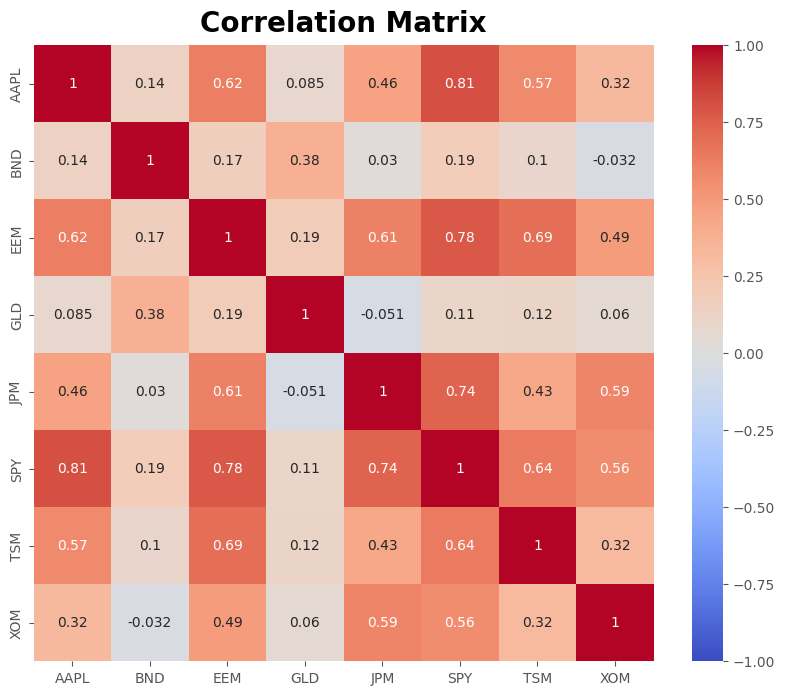

In [16]:
import seaborn as sns

plt.figure(figsize=(10,8))
sns.heatmap(log_returns.corr(), annot=True, cmap='coolwarm',vmin=-1)
plt.title('Correlation Matrix', fontsize=20, pad=10, fontweight='demibold')

### Bonds and Gold are uncorrelated with most assets.

# Day 2 - Equal-Weight Portfolio

## 2.1.1 Calculating Returns in 2 ways

In [17]:
#LOG VS SIMPLE TEST
initial_capital = 10000
equal_weights = np.array([1/data.columns.size] * data.columns.size)

### 2.1.1 SIMPLE DAILY RETURN (MU):

In [18]:
simple_returns = data.pct_change().dropna()
simple_returns

,AAPL,BND,EEM,GLD,JPM,SPY,TSM,XOM
Date,,,,,,,,
2019-01-03,-0.099608,0.003906,-0.018130,0.009066,-0.014212,-0.023863,-0.059146,-0.015353
2019-01-04,0.042689,-0.003012,0.032250,-0.008086,0.036865,0.033496,0.017753,0.036869
2019-01-07,-0.002226,-0.001511,0.002267,0.003458,0.000695,0.007885,0.007435,0.005200
2019-01-08,0.019063,-0.001261,0.003771,-0.002708,-0.001886,0.009395,-0.008232,0.007271
2019-01-09,0.016981,0.001389,0.017781,0.006418,-0.001690,0.004674,0.019176,0.005275
...,...,...,...,...,...,...,...,...
2023-12-22,-0.005548,-0.000667,-0.004802,0.004434,-0.000597,0.002010,0.005851,0.001770
2023-12-26,-0.002841,0.000954,0.007872,0.007621,0.005914,0.004223,0.012603,0.002257
2023-12-27,0.000518,0.006401,0.005795,0.004538,0.005998,0.001808,0.001915,-0.004699


In [19]:
#mu (average) simple - looks useless, but probably used in Markotitz (the other average simple returns are different...) - CHECK THIS!
#
mu_simple = simple_returns.mean() * 252
print(mu_simple)
print()
print(annualized_returns_average_asset)

AAPL    0.378031
BND     0.012835
EEM     0.053375
GLD     0.102324
JPM     0.189012
SPY     0.167224
TSM     0.298916
XOM     0.182362
dtype: float64

AAPL    38.52%
BND      1.06%
EEM      2.86%
GLD      9.54%
JPM     14.83%
SPY     15.61%
TSM     26.57%
XOM     13.16%
dtype: str


In [20]:
#actual returns (simple)
portfolio_simple = np.dot(simple_returns, equal_weights)
print(portfolio_simple.shape)
print()
print(portfolio_simple)

(1257,)

[-0.02716744  0.02360301  0.00290058 ...  0.00278411 -0.00081884
 -0.00283063]


In [21]:
#final wealth simple:
wealth_simple = initial_capital * (1 + portfolio_simple).cumprod()
wealth_simple

array([ 9728.32555473,  9957.9433019 ,  9986.82715856, ...,
       21953.95844712, 21935.98171791, 21873.88899825], shape=(1257,))

### 2.1.2. LOG METHOD

In [22]:
simple_returns

,AAPL,BND,EEM,GLD,JPM,SPY,TSM,XOM
Date,,,,,,,,
2019-01-03,-0.099608,0.003906,-0.018130,0.009066,-0.014212,-0.023863,-0.059146,-0.015353
2019-01-04,0.042689,-0.003012,0.032250,-0.008086,0.036865,0.033496,0.017753,0.036869
2019-01-07,-0.002226,-0.001511,0.002267,0.003458,0.000695,0.007885,0.007435,0.005200
2019-01-08,0.019063,-0.001261,0.003771,-0.002708,-0.001886,0.009395,-0.008232,0.007271
2019-01-09,0.016981,0.001389,0.017781,0.006418,-0.001690,0.004674,0.019176,0.005275
...,...,...,...,...,...,...,...,...
2023-12-22,-0.005548,-0.000667,-0.004802,0.004434,-0.000597,0.002010,0.005851,0.001770
2023-12-26,-0.002841,0.000954,0.007872,0.007621,0.005914,0.004223,0.012603,0.002257
2023-12-27,0.000518,0.006401,0.005795,0.004538,0.005998,0.001808,0.001915,-0.004699


In [23]:
daily_simple_returns = np.dot(simple_returns, equal_weights)
print(daily_simple_returns)
print()
print(daily_simple_returns.shape)

[-0.02716744  0.02360301  0.00290058 ...  0.00278411 -0.00081884
 -0.00283063]

(1257,)


In [24]:
#daily log return
daily_log_returns = np.log(1 + daily_simple_returns)
daily_log_returns


array([-0.0275433 ,  0.02332876,  0.00289639, ...,  0.00278025,
       -0.00081917, -0.00283465], shape=(1257,))

In [25]:
#total log return
total_log_return = daily_log_returns.sum()
total_log_return

np.float64(0.7827085493084049)

In [26]:
#total wealth
wealth_log = initial_capital * np.exp(total_log_return)
wealth_log

np.float64(21873.888998249746)

In [27]:
#for the wealth PATH use cumsum
wealth_log_path = initial_capital * np.exp(daily_log_returns.cumsum())
wealth_log_path

array([ 9728.32555473,  9957.9433019 ,  9986.82715856, ...,
       21953.95844712, 21935.98171791, 21873.88899825], shape=(1257,))

In [28]:
#the wealth paths are mathematically identical, so this methodology works, but the log path is more elegant and numerically stable in practice.
print(wealth_simple)
print(wealth_log_path)

[ 9728.32555473  9957.9433019   9986.82715856 ... 21953.95844712
 21935.98171791 21873.88899825]
[ 9728.32555473  9957.9433019   9986.82715856 ... 21953.95844712
 21935.98171791 21873.88899825]


In [29]:
# czyli jak mam log returns to sposob przejscia w faktyczny return jest troche inny - bo mam zagwarantwana addytywnosc w czasie,
# ale nie mam zagwarantowanej addytywnosci miedzy poszczegolnymi aktywami,
# wiec zeby to obejsc biore returns miedzy aktywami z simple, i potem zmieniam recznie na log. inaczej nie przeskocze chyba.
# wiec simple returns lepiej tutaj chyba wykorzystac. nie zyskuje nic z logow.
# robienie log_returns = np.log(data/data.shift(1)) mija sie z celem bo calego portfela tutaj nie zlicze.

In [30]:
df = pd.Series(wealth_simple, index=(data.index[1:]))
print(df)
print()

Date
2019-01-03     9728.325555
2019-01-04     9957.943302
2019-01-07     9986.827159
2019-01-08    10018.553006
2019-01-09    10106.218777
                  ...     
2023-12-22    21787.874326
2023-12-26    21893.005814
2023-12-27    21953.958447
2023-12-28    21935.981718
2023-12-29    21873.888998
Length: 1257, dtype: float64



In [31]:
df.name = "Wealth"

# Join it to the DataFrame
data_combined = data.join(df)
data_combined

,AAPL,BND,EEM,GLD,JPM,SPY,TSM,XOM,Wealth
Date,,,,,,,,,
2019-01-02,37.503735,64.321198,33.319088,121.330002,81.250206,224.995316,31.237253,50.001842,NaN
2019-01-03,33.768074,64.572441,32.714996,122.430000,80.095505,219.626312,29.389702,49.234142,9728.325555
2019-01-04,35.209614,64.377930,33.770046,121.440002,83.048256,226.982864,29.911455,51.049374,9957.943302
2019-01-07,35.131245,64.280670,33.846619,121.860001,83.105995,228.772552,30.133850,51.314842,9986.827159
2019-01-08,35.800957,64.199623,33.974255,121.529999,82.949287,230.921951,29.885803,51.687935,10018.553006
...,...,...,...,...,...,...,...,...,...
2023-12-22,191.609467,67.621140,37.554218,190.270004,159.387558,462.223328,100.357918,94.430161,21787.874326
2023-12-26,191.065125,67.685638,37.849842,191.720001,160.330200,464.175079,101.622711,94.643265,21893.005814
2023-12-27,191.164078,68.118896,38.069176,192.589996,161.291824,465.014313,101.817307,94.198502,21953.958447


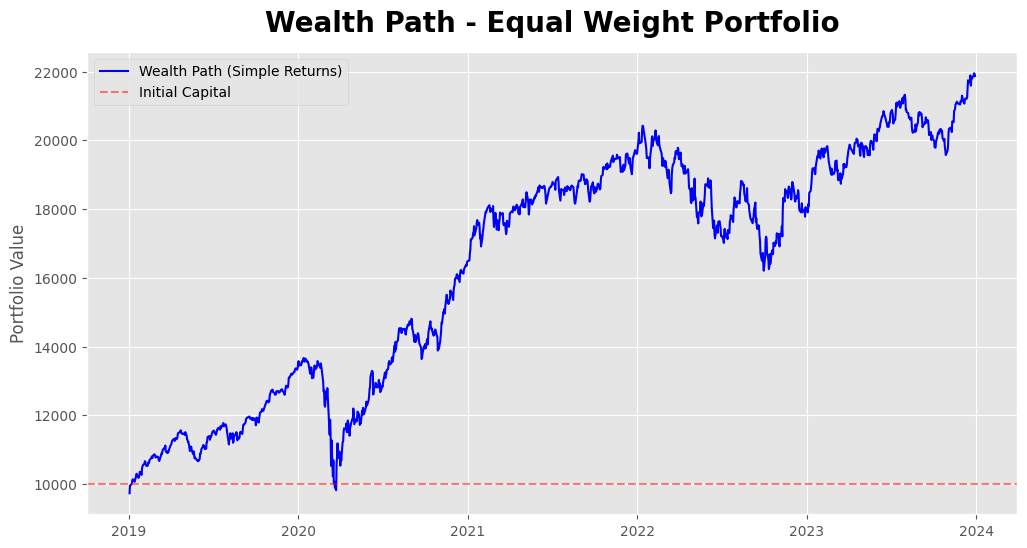

In [32]:
#vizing the wealth path.
plt.figure(figsize=(12, 6))
plt.plot(data_combined['Wealth'], label='Wealth Path (Simple Returns)', color='blue')
plt.axhline(y=initial_capital, color='red', linestyle='--', alpha=0.5, label='Initial Capital')
plt.title('Wealth Path - Equal Weight Portfolio', fontsize=20, pad=15, fontweight='bold')
plt.ylabel('Portfolio Value')
plt.legend()

In [33]:
#zle rozwiazanie
portfolio_log_wrong = np.dot(log_returns, equal_weights) # can't average logs across assets
portfolio_log_wrong


array([-0.02815038,  0.02317003,  0.00289005, ...,  0.00277412,
       -0.00084037, -0.00283667], shape=(1257,))

In [34]:
wealth_wrong = initial_capital * np.exp(portfolio_log_wrong.cumsum())
wealth_wrong

array([ 9722.4214709 ,  9950.32033222,  9979.11882242, ...,
       19907.18386657, 19890.46155356, 19834.11877262], shape=(1257,))

## 2.2. Equal-weight Portfolio Stats/Analysis - Reusable Function

In [35]:
# return rate: let's use the compound annual growth rate (CAGR) - it accounts for compounding (unlike annualized average simple return)
# It's a transformed yearly compounding formula.

### WRITING IT AGAIN TO THROW INTO A FUNCTION

In [36]:
equal_weights = np.ones(data.columns.size) / data.columns.size

In [37]:
eq_portfolio_returns = simple_returns @ equal_weights # equivalent to np.dot(simple_returns, equal_weights)
eq_portfolio_returns

Date
2019-01-03   -0.027167
2019-01-04    0.023603
2019-01-07    0.002901
2019-01-08    0.003177
2019-01-09    0.008750
                ...   
2023-12-22    0.000306
2023-12-26    0.004825
2023-12-27    0.002784
2023-12-28   -0.000819
2023-12-29   -0.002831
Length: 1257, dtype: float64

In [38]:
total_return_rate = (1 + eq_portfolio_returns).cumprod() - 1
total_return_rate

Date
2019-01-03   -0.027167
2019-01-04   -0.004206
2019-01-07   -0.001317
2019-01-08    0.001855
2019-01-09    0.010622
                ...   
2023-12-22    1.178787
2023-12-26    1.189301
2023-12-27    1.195396
2023-12-28    1.193598
2023-12-29    1.187389
Length: 1257, dtype: float64

In [39]:
# annualized average return rate - looks useless
annualized_average_return_rate = eq_portfolio_returns.mean() * trading_days
annualized_average_return_rate


np.float64(0.17300983370053674)

In [40]:
eq_portfolio_returns.mean()

np.float64(0.000686546959129114)

In [41]:
eq_portfolio_returns

Date
2019-01-03   -0.027167
2019-01-04    0.023603
2019-01-07    0.002901
2019-01-08    0.003177
2019-01-09    0.008750
                ...   
2023-12-22    0.000306
2023-12-26    0.004825
2023-12-27    0.002784
2023-12-28   -0.000819
2023-12-29   -0.002831
Length: 1257, dtype: float64

In [42]:
# volatility

# daily variance
print("daily variance:",eq_portfolio_returns.var())

# annualized variance
print("annalized variance", eq_portfolio_returns.var() * trading_days)

# annualized volatility
annualized_volatility = np.sqrt(eq_portfolio_returns.var() * trading_days)
print("annualized volatility", annualized_volatility)

daily variance: 0.00012687369780995384
annalized variance 0.03197217184810837
annualized volatility 0.17880763923308302


In [43]:
# calc volatility/std function
#def calculate_volatility (weights, data):
#    portfolio_returns = data.pct_change() @ weights
#    annualized_variance = portfolio_returns.var() * trading_days
#    annualized_volatility = np.sqrt(annualized_variance)
#    return annualized_volatility

In [44]:
from src.portfolio_stats import calculate_volatility

equal_weights = np.ones(len(tickers)) * (1 / len(tickers))

calculate_volatility(equal_weights, data)

np.float64(0.178807639233083)

In [45]:
# calc average return for sharpe

from src.portfolio_stats import calculate_mean_portfolio_returns

calculate_mean_portfolio_returns(equal_weights, data)

np.float64(0.17300983370053674)

In [46]:
data.pct_change() @ equal_weights

Date
2019-01-02         NaN
2019-01-03   -0.027167
2019-01-04    0.023603
2019-01-07    0.002901
2019-01-08    0.003177
                ...   
2023-12-22    0.000306
2023-12-26    0.004825
2023-12-27    0.002784
2023-12-28   -0.000819
2023-12-29   -0.002831
Length: 1258, dtype: float64

In [47]:
#looks like for the function to compare portfolio's all i'd need is one that takes in weights and the price data, and the rest i can calculate based on that
# i should have a few functions. one for returns CAGR? one for wealth path? for plotting? and then the whole statistics thing like volatility and sharpe ratios...

In [48]:
# i have the volatility. for sharpe ratio, i need the risk free rate and portfolio returns. 
# no, arithmetic average is what is typically use in Sharpe, and is an input into Markowitza and CAPM (despite it not reporting true return due to drag)
eq_portfolio_returns.mean() * trading_days

np.float64(0.17300983370053674)

In [49]:
#cagr for fun (compound annual growth rate)
years = data.shape[0] / 252
print(years)
cagr = (wealth_simple[-1] / initial_capital) ** (1 / years) - 1
print(f"CAGR: {cagr:.2%}")

4.992063492063492
CAGR: 16.98%


In [50]:
wealth_simple

array([ 9728.32555473,  9957.9433019 ,  9986.82715856, ...,
       21953.95844712, 21935.98171791, 21873.88899825], shape=(1257,))

In [51]:
#return at each time step


In [52]:
#return at each time step
from src.portfolio_stats import calculate_return_path

eq_return_path = calculate_return_path(equal_weights, data)
eq_return_path

array([       nan, 0.97283256, 0.99579433, ..., 2.19539584, 2.19359817,
       2.1873889 ], shape=(1258,))

In [53]:
#cagr function (for reporting true performance):
from src.portfolio_stats import calculate_cagr

calculate_cagr(equal_weights, data)

np.float64(0.1697506235237518)

In [55]:
from data_loader import read_rfr
rfr = read_rfr(start_date, end_date)

[*********************100%***********************]  1 of 1 completed


In [57]:
rfr

0.022721041324881567

In [58]:
#sharpe ratio of my portfolio: (Rp - rfr) / volatility
eq_sharpe_ratio = (annualized_average_return_rate - rfr) / annualized_volatility
eq_sharpe_ratio

np.float64(0.8405054337737082)

In [59]:
#sharpe ratio function
from src.portfolio_stats import calculate_sharpe_ratio

calculate_sharpe_ratio(equal_weights, data)

np.float64(0.8405054337737087)

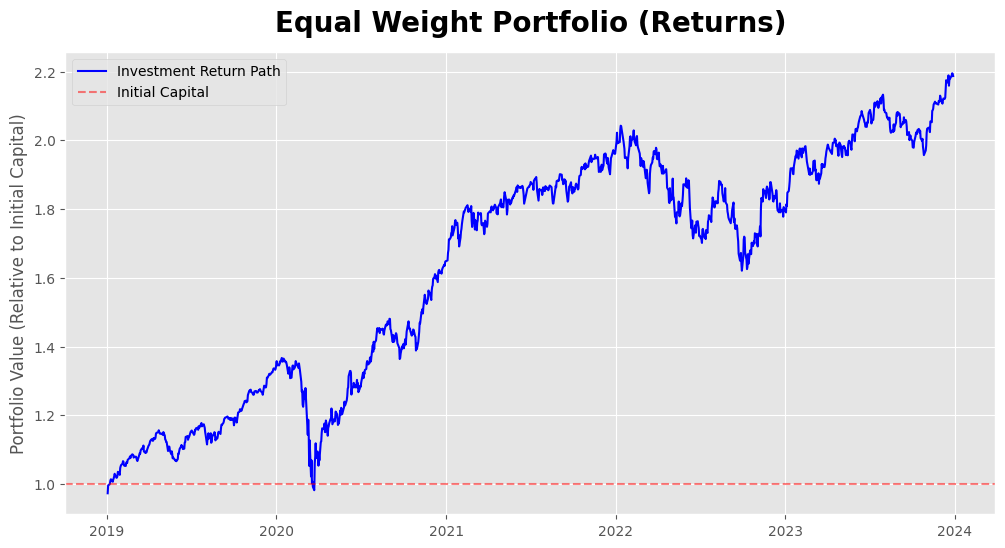

In [60]:
#viz return path (from function)
return_viz = calculate_return_path(equal_weights, data)

return_viz_series = pd.Series(return_viz, index=data.index)
return_viz_series

# viz
plt.figure(figsize=(12, 6))
plt.plot(return_viz_series, label='Investment Return Path', color='blue')
plt.axhline(y=1, color='red', linestyle='--', alpha=0.5, label='Initial Capital')
plt.title('Equal Weight Portfolio (Returns)', fontsize=20, pad=15, fontweight='bold')
plt.ylabel('Portfolio Value (Relative to Initial Capital)')
plt.legend()
plt.show()

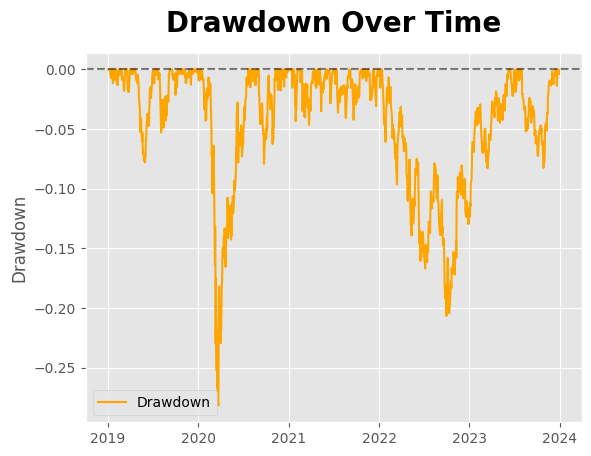

In [61]:
# computing drawdowns
return_viz_series.dropna()
drawdowns = (return_viz_series - return_viz_series.cummax()) / return_viz_series.cummax()
plt.plot(drawdowns, label='Drawdown', color='orange')
plt.axhline(0, color='black', linestyle='--', alpha=0.5)
plt.title('Drawdown Over Time', fontsize=20, pad=15, fontweight='bold')
plt.ylabel('Drawdown')
plt.legend()
plt.show()

In [62]:
max_drawdown = drawdowns.min()
max_drawdown

np.float64(-0.28168839339727314)

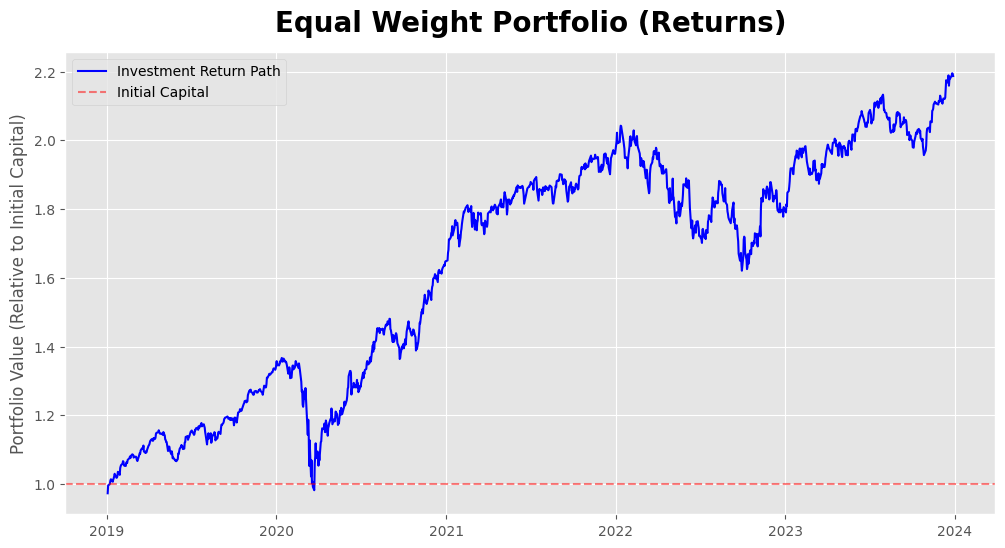

Total Return: 118.74%


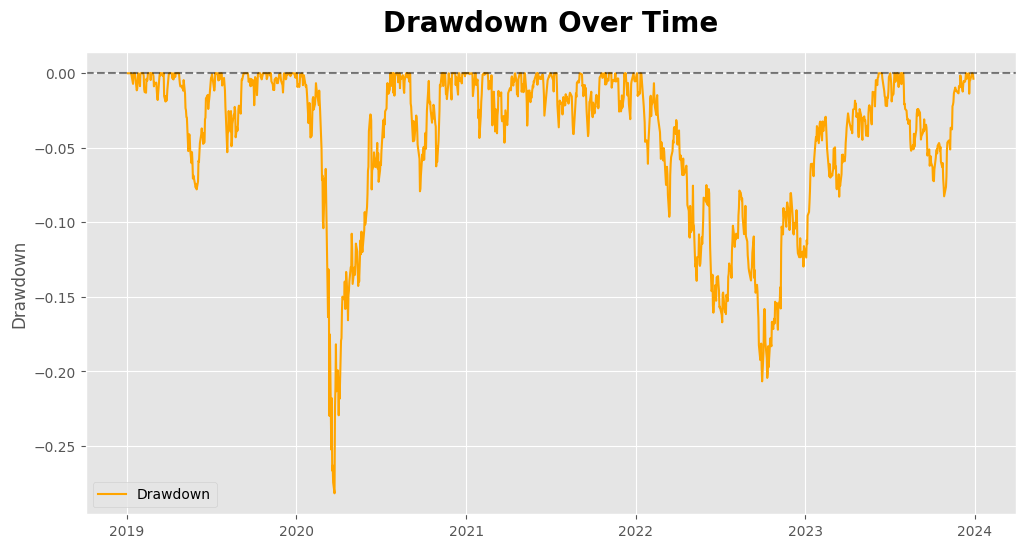

Maximum Drawdown: -28.17%


In [63]:
#CREATE A PLOTTING FUNCTION!
from src.vizualizations import plot_return_and_drawdown
plot_return_and_drawdown(equal_weights, data)

# Day 3 - MPT Optimization

## 3.1. Inputs I Need

In [64]:
# let's start from scratch to understand this

# inputs: mu, covar matrix

# mu - expected returns based on historical returns for each asset
mu = data.pct_change().mean() * trading_days
mu


AAPL    0.378031
BND     0.012835
EEM     0.053375
GLD     0.102324
JPM     0.189012
SPY     0.167224
TSM     0.298916
XOM     0.182362
dtype: float64

In [65]:
# sigma - annual covar matrix - this is used to compute risk
sigma = data.pct_change().cov() * trading_days
sigma.shape

(8, 8)

In [66]:
#functions needed:

#portfolio return (for each asset individually) based on mu (so an estimation, not accounting for compounding and non-additivity in time)
print(calculate_mean_portfolio_returns(equal_weights, data))

#portfolio volatility
print(calculate_volatility(equal_weights, data))

#sharpe ratio
calculate_sharpe_ratio(equal_weights, data)



0.17300983370053674
0.178807639233083


np.float64(0.8405054337737087)

In [67]:
#negative sharpe
from src.optimizations import calculate_negative_sharpe_ratio
calculate_negative_sharpe_ratio(equal_weights, data)

np.float64(-0.8405054337737087)

## 3.2. Global Minimum Variance Portfolio (GMVP)

In [68]:
#defining bounds and constraints for scipy
constraints = ({
    'type':'eq',
    'fun':lambda weights: np.sum(weights) - 1
    })

n = len(mu)
bounds = [(0,1)] * n

In [69]:
#define an initial guess for our variable
init_guess = equal_weights
init_guess

array([0.125, 0.125, 0.125, 0.125, 0.125, 0.125, 0.125, 0.125])

In [70]:
from scipy.optimize import minimize

In [71]:
minimum_variance_portfolio = minimize(calculate_volatility, init_guess, args=(data,), method='SLSQP', bounds=bounds, constraints=constraints)

In [72]:
minimum_variance_portfolio.x

array([1.35695860e-19, 9.19123113e-01, 3.64615919e-19, 3.21205135e-02,
       1.48450352e-02, 0.00000000e+00, 1.00305760e-18, 3.39113381e-02])

In [73]:
#the optimizer is saying that for the minimum global variance we should throw over 90% of the portfolio into bonds.
#what this serves as is a sort of benchmark - it's the leftmost point on the graph, and gives the minimum return we expect.

#let's check what the volatility is:
min_var_port_volatility = calculate_volatility(minimum_variance_portfolio.x, data)

#and what the retuns is (both average and CAGR):
min_var_port_mean_return = calculate_mean_portfolio_returns(minimum_variance_portfolio.x, data)
min_var_port_cagr = calculate_cagr(minimum_variance_portfolio.x, data)

#and the sharpe ratio:
min_var_port_sharpe = calculate_sharpe_ratio(minimum_variance_portfolio.x, data)

print('GMVP Volatility:', min_var_port_volatility)
print('GMVP Mean Returns:', min_var_port_mean_return)
print('GMVP CAGR', min_var_port_cagr)
print('GMVP Sharpe Ratio',min_var_port_sharpe)

GMVP Volatility: 0.06554126317269272
GMVP Mean Returns: 0.024073861044068775
GMVP CAGR 0.022142138260157873
GMVP Sharpe Ratio 0.020640733084786138


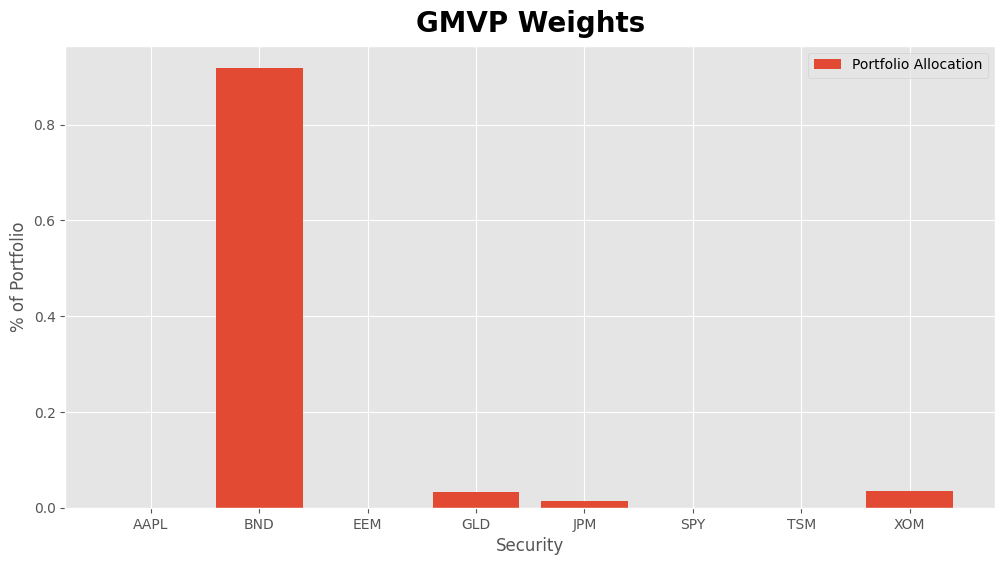

In [74]:
#plotting GMVP
plt.figure(figsize=(12,6))
plt.bar(data.columns, minimum_variance_portfolio.x, label='Portfolio Allocation')
plt.title('GMVP Weights', fontsize=20, pad=10, fontweight='semibold')
plt.xlabel('Security')
plt.ylabel('% of Portfolio')
plt.legend()

## 3.3. Tangency Portfolio (Max Sharpe Ratio)

In [75]:
#to maximize the sharpe we need to minimize the negative sharpe.

tangency_portfolio = minimize(calculate_negative_sharpe_ratio, init_guess, args=(data), constraints=constraints, bounds=bounds)
tangency_portfolio.x

array([4.49711073e-01, 2.63649029e-17, 3.30375192e-16, 4.39863318e-01,
       0.00000000e+00, 7.59915669e-17, 6.95109952e-02, 4.09146138e-02])

In [76]:
#calculating statistics

#let's check what the volatility is:
tangency_port_volatility = calculate_volatility(tangency_portfolio.x, data)

#and what the retuns is (both average and CAGR):
tangency_port_mean_return = calculate_mean_portfolio_returns(tangency_portfolio.x, data)
tangency_port_cagr = calculate_cagr(tangency_portfolio.x, data)

#and the sharpe ratio:
tangency_port_sharpe = calculate_sharpe_ratio(tangency_portfolio.x, data)

print('Tangency Portfolio Volatility:', tangency_port_volatility)
print('Tangency Portfolio Mean Returns:', tangency_port_mean_return)
print('Tangency Portfolio CAGR:', tangency_port_cagr)
print('Tangency Portfolio Sharpe Ratio:',tangency_port_sharpe)

Tangency Portfolio Volatility: 0.18390406170615217
Tangency Portfolio Mean Returns: 0.2432524051744931
Tangency Portfolio CAGR: 0.25365484264282445
Tangency Portfolio Sharpe Ratio: 1.1991652702156395


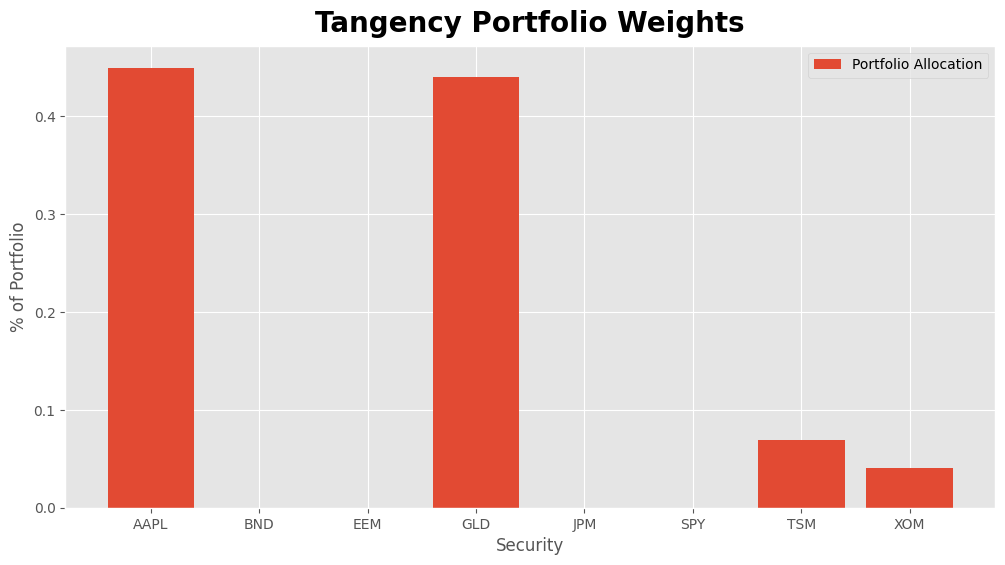

In [77]:
#plotting Tangency Portfolio
plt.figure(figsize=(12,6))
plt.bar(data.columns, tangency_portfolio.x, label='Portfolio Allocation')
plt.title('Tangency Portfolio Weights', fontsize=20, pad=10, fontweight='semibold')
plt.xlabel('Security')
plt.ylabel('% of Portfolio')
plt.legend()

In [78]:
calculate_return_path(equal_weights, data)

array([       nan, 0.97283256, 0.99579433, ..., 2.19539584, 2.19359817,
       2.1873889 ], shape=(1258,))

In [79]:
#calculating max drawdown
from src.portfolio_stats import calculate_max_drawdown

In [80]:
data

,AAPL,BND,EEM,GLD,JPM,SPY,TSM,XOM
Date,,,,,,,,
2019-01-02,37.503735,64.321198,33.319088,121.330002,81.250206,224.995316,31.237253,50.001842
2019-01-03,33.768074,64.572441,32.714996,122.430000,80.095505,219.626312,29.389702,49.234142
2019-01-04,35.209614,64.377930,33.770046,121.440002,83.048256,226.982864,29.911455,51.049374
2019-01-07,35.131245,64.280670,33.846619,121.860001,83.105995,228.772552,30.133850,51.314842
2019-01-08,35.800957,64.199623,33.974255,121.529999,82.949287,230.921951,29.885803,51.687935
...,...,...,...,...,...,...,...,...
2023-12-22,191.609467,67.621140,37.554218,190.270004,159.387558,462.223328,100.357918,94.430161
2023-12-26,191.065125,67.685638,37.849842,191.720001,160.330200,464.175079,101.622711,94.643265
2023-12-27,191.164078,68.118896,38.069176,192.589996,161.291824,465.014313,101.817307,94.198502


## 3.4. Maximum Returns For Given Volatility Levels

In [81]:
#maximizing returns for a given level of volatility - run it across a few: vol_targets = np.linspace(0.08, 0.25, 20)

#reassigning variables to have everything in one place:
n = len(data.columns)
bounds = [(0,1)] * n
init_guess = (np.ones(n)) / 8


In [82]:
from src.optimizations import optimize_portfolios

optimized_port_stats_df, optimized_weights_df = optimize_portfolios(data, 0.06, 0.25, 20)
optimized_port_stats_df

calculating optimal portfolio with 0.06 annualized volatility
calculating optimal portfolio with 0.07 annualized volatility
calculating optimal portfolio with 0.08 annualized volatility
calculating optimal portfolio with 0.09 annualized volatility
calculating optimal portfolio with 0.1 annualized volatility
calculating optimal portfolio with 0.11 annualized volatility
calculating optimal portfolio with 0.12 annualized volatility
calculating optimal portfolio with 0.13 annualized volatility
calculating optimal portfolio with 0.14 annualized volatility
calculating optimal portfolio with 0.15 annualized volatility
calculating optimal portfolio with 0.16 annualized volatility
calculating optimal portfolio with 0.17 annualized volatility
calculating optimal portfolio with 0.18 annualized volatility
calculating optimal portfolio with 0.19 annualized volatility
calculating optimal portfolio with 0.2 annualized volatility
calculating optimal portfolio with 0.21 annualized volatility
calculatin

,Volatility,Max Drawdown,Mean Return,CAGR,Sharpe Ratio
0,0.06,0.151604,0.024136,0.022206,0.021590
1,0.07,0.141040,0.054444,0.053312,0.453185
2,0.08,0.138878,0.082036,0.081938,0.741440
3,0.09,0.138513,0.102542,0.103391,0.886900
4,0.10,0.139654,0.120512,0.122310,0.977908
5,0.11,0.141139,0.137143,0.139912,1.040202
6,0.12,0.147520,0.152949,0.156721,1.085236
7,0.13,0.154637,0.168199,0.173007,1.119059
8,0.14,0.164186,0.183050,0.188930,1.145207
9,0.15,0.173506,0.197605,0.204591,1.165890


In [83]:
optimized_weights_df

,AAPL,BND,EEM,GLD,JPM,SPY,TSM,XOM
0,6.603912e-14,9.187760e-01,2.403308e-15,0.032069,1.472644e-02,4.103183e-16,8.060197e-16,0.034429
1,5.205939e-02,7.690103e-01,0.000000e+00,0.113481,1.926144e-02,5.728056e-18,1.045139e-02,0.035737
2,1.033585e-01,6.377689e-01,1.654481e-17,0.183210,2.115212e-02,0.000000e+00,1.795110e-02,0.036559
3,1.414901e-01,5.402327e-01,4.149774e-17,0.235046,2.251472e-02,1.780258e-17,2.352318e-02,0.037193
4,1.749103e-01,4.548853e-01,0.000000e+00,0.280287,2.374843e-02,5.450700e-17,2.845475e-02,0.037714
5,2.058157e-01,3.756859e-01,0.000000e+00,0.322451,2.488328e-02,0.000000e+00,3.295690e-02,0.038208
6,2.348403e-01,3.002006e-01,3.194583e-17,0.362601,2.618872e-02,1.185533e-16,3.754648e-02,0.038623
7,2.634462e-01,2.279243e-01,0.000000e+00,0.400974,2.715387e-02,1.484516e-17,4.153110e-02,0.038970
8,2.911502e-01,1.573194e-01,1.427285e-17,0.438441,2.830484e-02,0.000000e+00,4.540965e-02,0.039375
9,3.180735e-01,8.790518e-02,0.000000e+00,0.475489,2.862936e-02,7.251940e-17,4.954736e-02,0.040356


## 3.5. Plotting Efficient Frontier

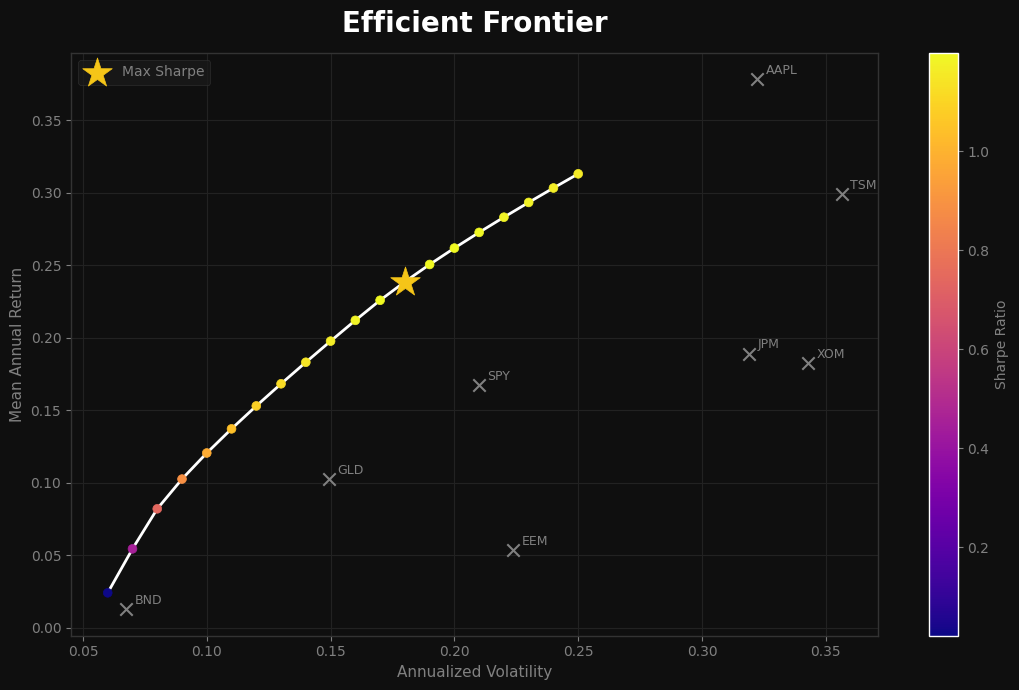

In [84]:
# plotting the efficient frontier
fig, ax = plt.subplots(figsize=(11, 7))
fig.patch.set_facecolor('#0f0f0f')
ax.set_facecolor('#0f0f0f')

# frontier line
ax.plot(optimized_port_stats_df['Volatility'], optimized_port_stats_df['Mean Return'],
        color='white', linewidth=2, zorder=2)

# frontier points colored by sharpe ratio
sc = ax.scatter(optimized_port_stats_df['Volatility'], optimized_port_stats_df['Mean Return'],
                c=optimized_port_stats_df['Sharpe Ratio'], cmap='plasma',
                s=40, zorder=3)
cbar = plt.colorbar(sc, ax=ax)
cbar.set_label('Sharpe Ratio', color='grey', fontsize=10)
cbar.ax.yaxis.set_tick_params(color='grey')
plt.setp(cbar.ax.yaxis.get_ticklabels(), color='grey')

# individual assets
for col in data.columns:
    single_weight = np.zeros(n)
    single_weight[list(data.columns).index(col)] = 1.0
    asset_vol = calculate_volatility(single_weight, data)
    asset_ret = calculate_mean_portfolio_returns(single_weight, data)
    ax.scatter(asset_vol, asset_ret, marker='x', s=80, color='grey', zorder=4, linewidths=1.5)
    ax.annotate(col, (asset_vol, asset_ret), textcoords="offset points",
                xytext=(6, 4), color='grey', fontsize=9)

# max sharpe portfolio
max_sharpe_idx = optimized_port_stats_df['Sharpe Ratio'].idxmax()
best = optimized_port_stats_df.loc[max_sharpe_idx]
ax.scatter(best['Volatility'], best['Mean Return'],
           color='#f5c518', s=500, zorder=5, marker='*', label='Max Sharpe')

# formatting
ax.set_xlabel('Annualized Volatility', color='grey', fontsize=11)
ax.set_ylabel('Mean Annual Return', color='grey', fontsize=11)
ax.set_title('Efficient Frontier', color='white', fontsize=20, fontweight='bold', pad=15)
ax.tick_params(colors='grey')
for spine in ax.spines.values():
    spine.set_edgecolor('#333333')
ax.grid(True, color='#222222', linewidth=0.8)
ax.legend(facecolor='#1a1a1a', edgecolor='#333333', labelcolor='grey', fontsize=10)

plt.tight_layout()
plt.show()

In [85]:
optimized_weights_df

,AAPL,BND,EEM,GLD,JPM,SPY,TSM,XOM
0,6.603912e-14,9.187760e-01,2.403308e-15,0.032069,1.472644e-02,4.103183e-16,8.060197e-16,0.034429
1,5.205939e-02,7.690103e-01,0.000000e+00,0.113481,1.926144e-02,5.728056e-18,1.045139e-02,0.035737
2,1.033585e-01,6.377689e-01,1.654481e-17,0.183210,2.115212e-02,0.000000e+00,1.795110e-02,0.036559
3,1.414901e-01,5.402327e-01,4.149774e-17,0.235046,2.251472e-02,1.780258e-17,2.352318e-02,0.037193
4,1.749103e-01,4.548853e-01,0.000000e+00,0.280287,2.374843e-02,5.450700e-17,2.845475e-02,0.037714
5,2.058157e-01,3.756859e-01,0.000000e+00,0.322451,2.488328e-02,0.000000e+00,3.295690e-02,0.038208
6,2.348403e-01,3.002006e-01,3.194583e-17,0.362601,2.618872e-02,1.185533e-16,3.754648e-02,0.038623
7,2.634462e-01,2.279243e-01,0.000000e+00,0.400974,2.715387e-02,1.484516e-17,4.153110e-02,0.038970
8,2.911502e-01,1.573194e-01,1.427285e-17,0.438441,2.830484e-02,0.000000e+00,4.540965e-02,0.039375
9,3.180735e-01,8.790518e-02,0.000000e+00,0.475489,2.862936e-02,7.251940e-17,4.954736e-02,0.040356


## 3.6. Plotting Optimal Weights For Each Portfolio

/var/folders/4v/1cr4vn8x4yv_p93m1plqw2s80000gn/T/ipykernel_35622/1803478418.py:20: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(x, rotation=45, ha='right')


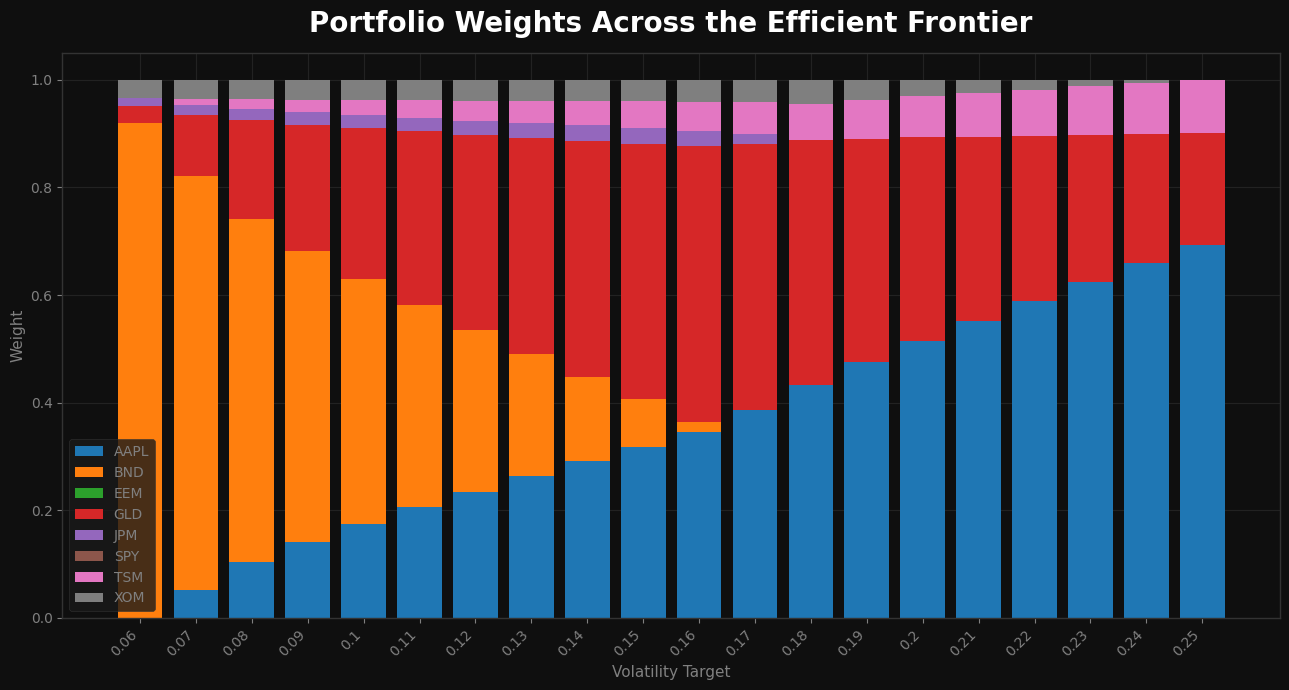

In [86]:
fig, ax = plt.subplots(figsize=(13, 7))
fig.patch.set_facecolor('#0f0f0f')
ax.set_facecolor('#0f0f0f')

weights_only = optimized_weights_df.drop(columns='Volatility') if 'Volatility' in optimized_weights_df.columns else optimized_weights_df
x = optimized_port_stats_df['Volatility'].round(3).astype(str)
bottom = np.zeros(len(optimized_weights_df))

#colors = plt.cm.plasma(np.linspace(0.1, 0.9, n))
colors = plt.cm.tab10.colors

for i, col in enumerate(weights_only.columns):
    ax.bar(x, weights_only[col], bottom=bottom, label=col, color=colors[i])
    bottom += weights_only[col].values

ax.set_xlabel('Volatility Target', color='grey', fontsize=11)
ax.set_ylabel('Weight', color='grey', fontsize=11)
ax.set_title('Portfolio Weights Across the Efficient Frontier', color='white', fontsize=20, fontweight='bold', pad=15)
ax.tick_params(colors='grey')
ax.set_xticklabels(x, rotation=45, ha='right')
for spine in ax.spines.values():
    spine.set_edgecolor('#333333')
ax.grid(True, color='#222222', linewidth=0.8)
ax.legend(facecolor='#1a1a1a', edgecolor='#333333', labelcolor='grey', fontsize=10)

plt.tight_layout()
plt.show()

### digression...

In [87]:
#checking gold performance because the optimizer seems to like it - not great - the lack of correlation to other assets must be the reason.

annualized_covar_matrix

,AAPL,BND,EEM,GLD,JPM,SPY,TSM,XOM
AAPL,0.104004,0.003023,0.044897,0.004116,0.047067,0.054788,0.065439,0.035702
BND,0.003023,0.004583,0.002593,0.003841,0.000653,0.002653,0.002432,-0.000732
EEM,0.044897,0.002593,0.050666,0.006315,0.043811,0.036959,0.055228,0.037788
GLD,0.004116,0.003841,0.006315,0.022351,-0.002446,0.003392,0.006189,0.003077
JPM,0.047067,0.000653,0.043811,-0.002446,0.101373,0.049386,0.048265,0.064863
SPY,0.054788,0.002653,0.036959,0.003392,0.049386,0.044449,0.047560,0.040244
TSM,0.065439,0.002432,0.055228,0.006189,0.048265,0.047560,0.126200,0.038406
XOM,0.035702,-0.000732,0.037788,0.003077,0.064863,0.040244,0.038406,0.117536


In [88]:
data.columns

Index(['AAPL', 'BND', 'EEM', 'GLD', 'JPM', 'SPY', 'TSM', 'XOM'], dtype='str')

In [89]:
gold_portfolio = np.zeros(len(data.columns))
gold_portfolio[3] = 1
gold_return = calculate_return_path(gold_portfolio, data)

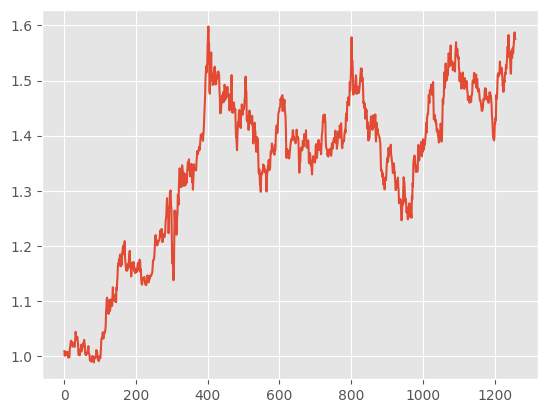

In [90]:
plt.plot(gold_return)

In [91]:
annualized_returns_average_asset

AAPL    38.52%
BND      1.06%
EEM      2.86%
GLD      9.54%
JPM     14.83%
SPY     15.61%
TSM     26.57%
XOM     13.16%
dtype: str

## 3.7 Sensitivity Test

<BarContainer object of 8 artists>

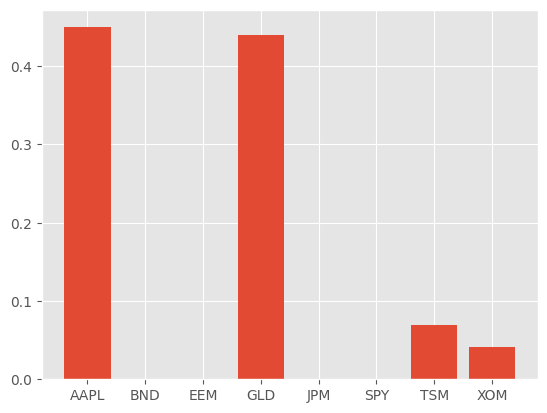

In [92]:
#LASTLY: CHECKING MPTs SENSITIVITY TO THE INPUT - TRYING DIFFERENT TIME-FRAMES AS INPUT

#comparing tangency portfolios:
plt.bar(data.columns, tangency_portfolio.x)


In [93]:
tickers

['TSM', 'AAPL', 'JPM', 'XOM', 'EEM', 'SPY', 'GLD', 'BND']

In [94]:
data_6y = yf.download(tickers, start='2018-01-01', end='2024-01-01', auto_adjust=True)['Close']
data_7y = yf.download(tickers, start='2015-01-01', end='2024-01-01', auto_adjust=True)['Close']
data_3y = yf.download(tickers, start='2021-01-01', end='2024-01-01', auto_adjust=True)['Close']

[*********************100%***********************]  8 of 8 completed
[*********************100%***********************]  8 of 8 completed
[*********************100%***********************]  8 of 8 completed


In [95]:
tangency_portfolio_6y = minimize(calculate_negative_sharpe_ratio, init_guess, args=(data_6y), constraints=constraints, bounds=bounds)
tangency_portfolio_7y = minimize(calculate_negative_sharpe_ratio, init_guess, args=(data_7y), constraints=constraints, bounds=bounds)
tangency_portfolio_3y = minimize(calculate_negative_sharpe_ratio, init_guess, args=(data_3y), constraints=constraints, bounds=bounds)

/var/folders/4v/1cr4vn8x4yv_p93m1plqw2s80000gn/T/ipykernel_35622/3430591236.py:20: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(data.columns, rotation=45, ha='right')
/var/folders/4v/1cr4vn8x4yv_p93m1plqw2s80000gn/T/ipykernel_35622/3430591236.py:20: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(data.columns, rotation=45, ha='right')
/var/folders/4v/1cr4vn8x4yv_p93m1plqw2s80000gn/T/ipykernel_35622/3430591236.py:20: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(data.columns, rotation=45, ha='right')


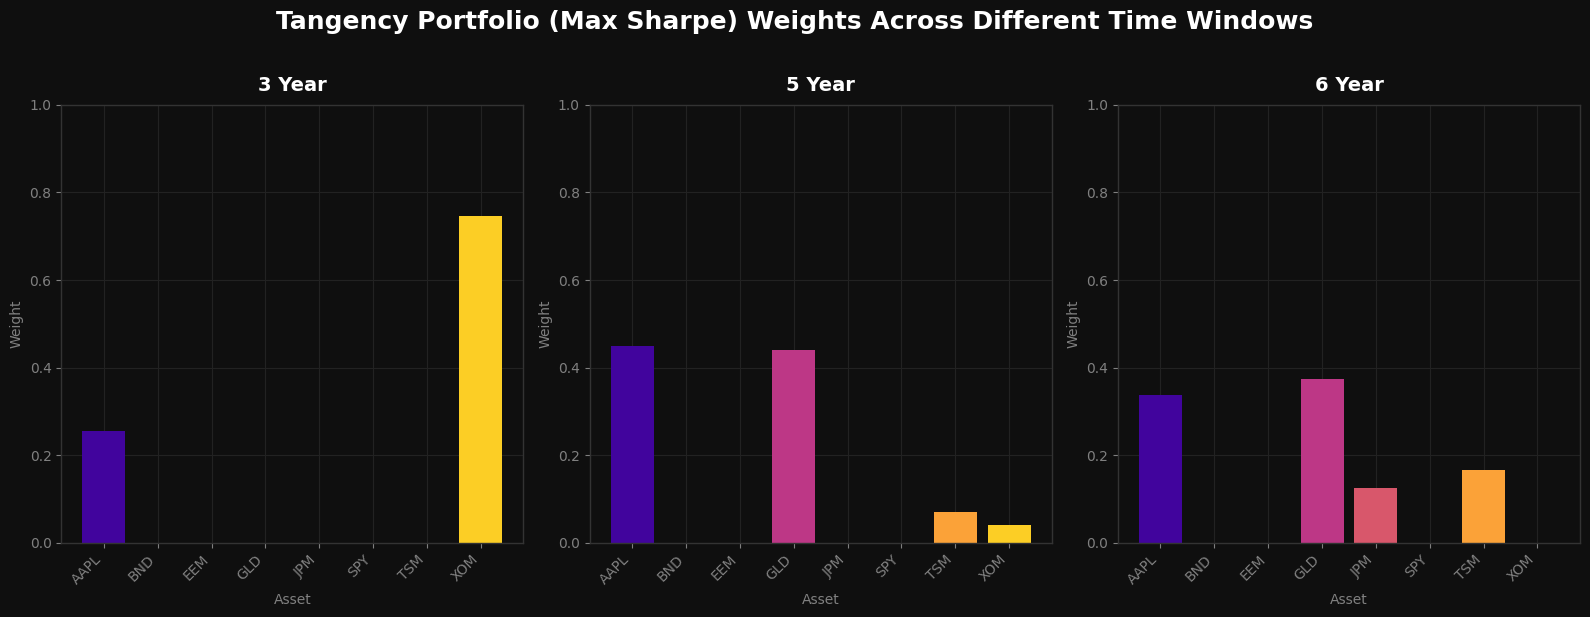

In [96]:
portfolios = {
    '3 Year': tangency_portfolio_3y,
    '5 Year': tangency_portfolio,
    '6 Year': tangency_portfolio_7y,
}

fig, axes = plt.subplots(1, 3, figsize=(16, 6))
fig.patch.set_facecolor('#0f0f0f')

for ax, (label, portfolio) in zip(axes, portfolios.items()):
    weights = portfolio.x
    ax.bar(data.columns, weights, color=plt.cm.plasma(np.linspace(0.1, 0.9, n)))
    
    # formatting
    ax.set_facecolor('#0f0f0f')
    ax.set_title(label, color='white', fontsize=14, fontweight='bold', pad=10)
    ax.set_xlabel('Asset', color='grey', fontsize=10)
    ax.set_ylabel('Weight', color='grey', fontsize=10)
    ax.tick_params(colors='grey')
    ax.set_xticklabels(data.columns, rotation=45, ha='right')
    for spine in ax.spines.values():
        spine.set_edgecolor('#333333')
    ax.grid(True, color='#222222', linewidth=0.8)
    ax.set_ylim(0, 1)

fig.suptitle('Tangency Portfolio (Max Sharpe) Weights Across Different Time Windows', 
             color='white', fontsize=18, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

In [97]:
# the graph above shows the huge sensitivity and over-reliance of MVO on the historical data you feed it. 

# Markowitz assumes expected returns are stationary — that the true mean return is a fixed number you're trying to estimate.
# But asset returns aren't stationary. Companies change, industries change, macro regimes change.
# No amount of historical data gives you a reliable estimate of future expected returns because the future distribution
# is genuinely different from the past one.

# Day 4 - CAPM

## 4.1. Calculating Betas

In [98]:
from scipy.stats import linregress

#we will use SPY as a benchmark
spy_returns = data['SPY'].pct_change().dropna()
betas = {}
r2s = {}

#calculating betas into a dictionary
for col in data.columns:
    if col == 'SPY':
        continue
    asset_returns = data[col].pct_change().dropna()
    slope, intercept, r, p, se = linregress(spy_returns, asset_returns)
    betas[col] = slope
    r2s[col] = r**2


#turning into series for easier access.
betas_series = pd.Series(betas)
r2s_series = pd.Series(r2s)
print(betas_series)

AAPL    1.235198
BND     0.059259
EEM     0.827129
GLD     0.076613
JPM     1.112260
TSM     1.070613
XOM     0.900521
dtype: float64


In [99]:
#computing CAPM esitmated returns
spy_returns_annual = spy_returns.mean() * trading_days
capm_estimated_returns = rfr + betas_series * (spy_returns_annual - rfr)
capm_estimated_returns


AAPL    0.201211
BND     0.031284
EEM     0.142244
GLD     0.033792
JPM     0.183446
TSM     0.177428
XOM     0.152849
dtype: float64

In [100]:
#historic mean/expected asset returns
asset_annual_mean_returns = data.pct_change().mean() * trading_days
asset_annual_mean_returns

AAPL    0.378031
BND     0.012835
EEM     0.053375
GLD     0.102324
JPM     0.189012
SPY     0.167224
TSM     0.298916
XOM     0.182362
dtype: float64

In [101]:
#compare actual with predicted:
capm_comparison_df = pd.DataFrame({'Betas': betas_series,
                                   'CAPM Estimation': capm_estimated_returns,
                                   'Real Mean Returns' : asset_annual_mean_returns,
                                   'Variance Explained by CAPM' : r2s})

capm_comparison_df = capm_comparison_df.dropna(axis=0) # dropping SPY - which has NaN because it's the benchmark

#CONCLUSION: capm estimated returns edviate significantly from actual mean returns for the majority of assets.
#the 1 factor (market exposure) that capm uses to estimate returns doesn't explain nearly enough variance in the markets.

In [102]:
capm_comparison_df

,Betas,CAPM Estimation,Real Mean Returns,Variance Explained by CAPM
AAPL,1.235198,0.201211,0.378031,0.647281
BND,0.059259,0.031284,0.012835,0.033928
EEM,0.827129,0.142244,0.053375,0.602529
GLD,0.076613,0.033792,0.102324,0.011597
JPM,1.112260,0.183446,0.189012,0.535989
TSM,1.070613,0.177428,0.298916,0.397942
XOM,0.900521,0.152849,0.182362,0.304277


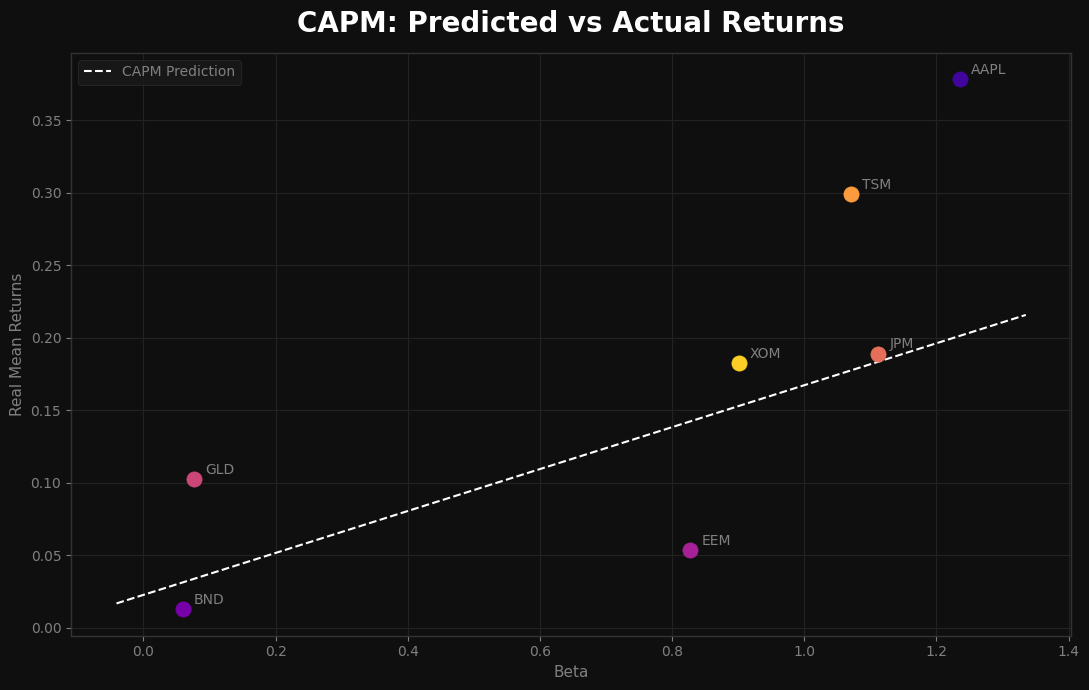

In [103]:
fig, ax = plt.subplots(figsize=(11, 7))
fig.patch.set_facecolor('#0f0f0f')
ax.set_facecolor('#0f0f0f')

# CAPM line
x_line = np.linspace(capm_comparison_df['Betas'].min() - 0.1, capm_comparison_df['Betas'].max() + 0.1, 100)
y_line = rfr + x_line * (spy_returns_annual - rfr)
ax.plot(x_line, y_line, color='white', linewidth=1.5, linestyle='--', label='CAPM Prediction', zorder=2)

# one scatter point per asset
colors = plt.cm.plasma(np.linspace(0.1, 0.9, len(capm_comparison_df)))
for i, (asset, row) in enumerate(capm_comparison_df.iterrows()):
    ax.scatter(row['Betas'], row['Real Mean Returns'], color=colors[i], s=120, zorder=3)
    ax.annotate(asset, (row['Betas'], row['Real Mean Returns']),
                textcoords="offset points", xytext=(8, 4), color='grey', fontsize=10)

# formatting
ax.set_xlabel('Beta', color='grey', fontsize=11)
ax.set_ylabel('Real Mean Returns', color='grey', fontsize=11)
ax.set_title('CAPM: Predicted vs Actual Returns', color='white', fontsize=20, fontweight='bold', pad=15)
ax.tick_params(colors='grey')
for spine in ax.spines.values():
    spine.set_edgecolor('#333333')
ax.grid(True, color='#222222', linewidth=0.8)
ax.legend(facecolor='#1a1a1a', edgecolor='#333333', labelcolor='grey', fontsize=10)

plt.tight_layout()
plt.show()

In [104]:
# if returns were 100% accurate, the asset returns would sit on the capm line
# this shows that the 1 factor doesnt explain nearly enough variance to be useful.

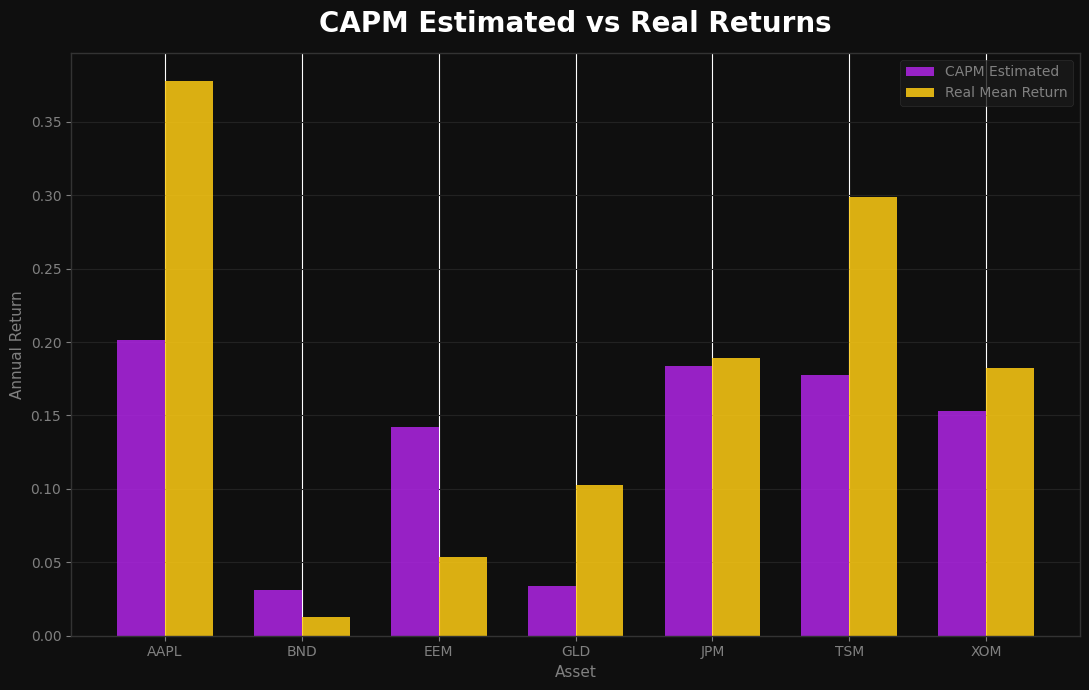

In [105]:
fig, ax = plt.subplots(figsize=(11, 7))
fig.patch.set_facecolor('#0f0f0f')
ax.set_facecolor('#0f0f0f')

x = np.arange(len(capm_comparison_df))
width = 0.35

ax.bar(x - width/2, capm_comparison_df['CAPM Estimation'], width, 
       label='CAPM Estimated', color="#b025e6", alpha=0.85)
ax.bar(x + width/2, capm_comparison_df['Real Mean Returns'], width, 
       label='Real Mean Return', color="#ffcc13", alpha=0.85)

ax.set_xticks(x)
ax.set_xticklabels(capm_comparison_df.index, color='grey', fontsize=10)
ax.set_xlabel('Asset', color='grey', fontsize=11)
ax.set_ylabel('Annual Return', color='grey', fontsize=11)
ax.set_title('CAPM Estimated vs Real Returns', color='white', fontsize=20, fontweight='bold', pad=15)
ax.tick_params(colors='grey')
for spine in ax.spines.values():
    spine.set_edgecolor('#333333')
ax.grid(True, color='#222222', linewidth=0.8, axis='y')
ax.legend(facecolor='#1a1a1a', edgecolor='#333333', labelcolor='grey', fontsize=10)

plt.tight_layout()
plt.show()

# Day 5 - Out of Sample Performance Test

In [106]:
#training on 3 years, then checking performance on latter 2.

In [107]:
train_start_date = '2019-01-03'
train_end_date = '2021-12-31'
test_start_date = '2022-01-01'
test_end_date = '2023-12-31'

train_data = data.loc[train_start_date : train_end_date]
test_data = data.loc[test_start_date : test_end_date]

In [108]:
train_data

,AAPL,BND,EEM,GLD,JPM,SPY,TSM,XOM
Date,,,,,,,,
2019-01-03,33.768074,64.572441,32.714996,122.430000,80.095505,219.626312,29.389702,49.234142
2019-01-04,35.209614,64.377930,33.770046,121.440002,83.048256,226.982864,29.911455,51.049374
2019-01-07,35.131245,64.280670,33.846619,121.860001,83.105995,228.772552,30.133850,51.314842
2019-01-08,35.800957,64.199623,33.974255,121.529999,82.949287,230.921951,29.885803,51.687935
2019-01-09,36.408909,64.288780,34.578339,122.309998,82.809074,232.001190,30.458881,51.960583
...,...,...,...,...,...,...,...,...
2021-12-27,176.459717,73.956093,44.365379,169.369995,141.756668,451.449524,114.628281,53.338226
2021-12-28,175.442017,73.947365,44.220329,168.639999,142.186859,451.080627,114.030380,53.165863
2021-12-29,175.530106,73.703377,44.020901,168.589996,142.115173,451.657562,113.423134,52.700474


In [109]:
init_guess

array([0.125, 0.125, 0.125, 0.125, 0.125, 0.125, 0.125, 0.125])

In [111]:
from data_loader import read_rfr
rfr = read_rfr(start_date, end_date)

[*********************100%***********************]  1 of 1 completed


In [112]:
rfr

0.022721041324881567

In [113]:
#fitting tangency portfolio on train data
rfr = read_rfr(train_start_date, train_end_date)
print('RFR Train:',rfr)

constraints_train = ({
    'type':'eq',
    'fun':lambda weights: np.sum(weights) - 1
    })

n = len(train_data.columns)
bounds_train = [(0,1)] * n

tangency_portfolio_train = minimize(calculate_negative_sharpe_ratio, init_guess, args=(train_data,), constraints=constraints_train, bounds=bounds_train)

[*********************100%***********************]  1 of 1 completed

RFR Train: 0.014843827791561355


Text(0.5, 1.0, 'Tangency Portfolio Weights (Stress Test)')

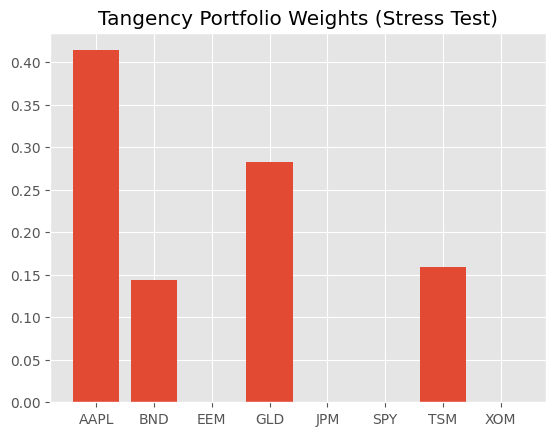

In [114]:
plt.bar(train_data.columns, tangency_portfolio_train.x)
plt.title('Tangency Portfolio Weights (Stress Test)')

In [115]:
#reporting train performance:
print('Train Data Performance:')
tangency_port_train_volatility = calculate_volatility(tangency_portfolio_train.x, train_data)
tangency_port_train_mean_return = calculate_mean_portfolio_returns(tangency_portfolio_train.x, train_data)
tangency_port_train_cagr = calculate_cagr(tangency_portfolio_train.x, train_data)
tangency_port_train_sharpe = calculate_sharpe_ratio(tangency_portfolio_train.x, train_data)

print('Train Tangency Portfolio Volatility:', tangency_port_train_volatility)
print('Train Tangency Portfolio Mean Returns:', tangency_port_train_mean_return)
print('Train Tangency Portfolio CAGR:', tangency_port_train_cagr)
print('Train Tangency Portfolio Sharpe Ratio:',tangency_port_train_sharpe)

#comparing to test performance:
print('Test Data Performance:')
tangency_port_test_volatility = calculate_volatility(tangency_portfolio_train.x, test_data)
tangency_port_test_mean_return = calculate_mean_portfolio_returns(tangency_portfolio_train.x, test_data)
tangency_port_test_cagr = calculate_cagr(tangency_portfolio_train.x, test_data)
tangency_port_test_sharpe = calculate_sharpe_ratio(tangency_portfolio_train.x, test_data)

print('Test Tangency Portfolio Volatility:', tangency_port_test_volatility)
print('Test Tangency Portfolio Mean Returns:', tangency_port_test_mean_return)
print('Test Tangency Portfolio CAGR:', tangency_port_test_cagr)
print('Test Tangency Portfolio Sharpe Ratio:',tangency_port_test_sharpe)

Train Data Performance:
Train Tangency Portfolio Volatility: 0.1888171905168201
Train Tangency Portfolio Mean Returns: 0.3730468718628638
Train Tangency Portfolio CAGR: 0.42546140766223783
Train Tangency Portfolio Sharpe Ratio: 1.8553704224657168
Test Data Performance:
Test Tangency Portfolio Volatility: 0.17238220498286613
Test Tangency Portfolio Mean Returns: 0.04329866398884151
Test Tangency Portfolio CAGR: 0.028847539417271584
Test Tangency Portfolio Sharpe Ratio: 0.11937208174129872


In [116]:
#plotting the return paths throughout the test and train period for the portfolio
stress_test_return_path = calculate_return_path(tangency_portfolio_train.x, data)

#converting into series for earlier plotting
stress_test_return_path = pd.Series(stress_test_return_path, index=data.index)
stress_test_return_path.dropna()

Date
2019-01-03    0.952431
2019-01-04    0.969380
2019-01-07    0.970373
2019-01-08    0.975843
2019-01-09    0.987656
                ...   
2023-12-22    2.964509
2023-12-26    2.973770
2023-12-27    2.981865
2023-12-28    2.978898
2023-12-29    2.966723
Length: 1257, dtype: float64

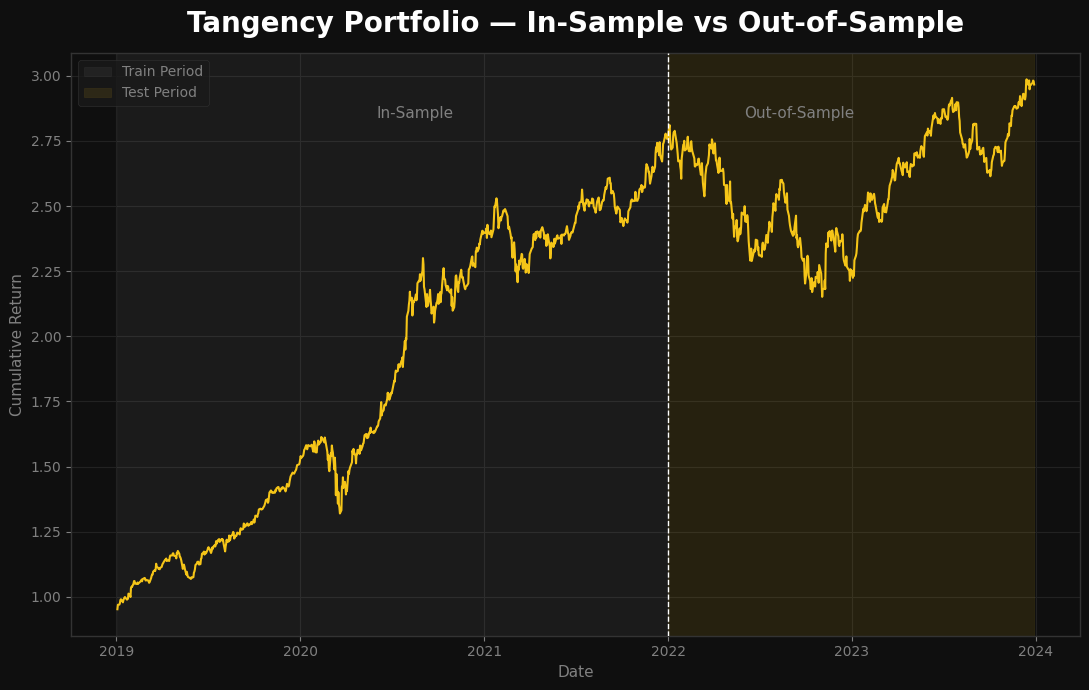

In [117]:
#return path across 5 years with the weights fitted on the first three.

fig, ax = plt.subplots(figsize=(11, 7))
fig.patch.set_facecolor('#0f0f0f')
ax.set_facecolor('#0f0f0f')

# plot the return path
ax.plot(stress_test_return_path.index, stress_test_return_path.values,
        color='#f5c518', linewidth=1.5, zorder=2)

# vertical line separating train and test
split_date = '2022-01-01'
ax.axvline(x=pd.Timestamp(split_date), color='white', linewidth=1, linestyle='--', zorder=3)

# shade the two regions
ax.axvspan(stress_test_return_path.index[0], pd.Timestamp(split_date),
           alpha=0.05, color='white', label='Train Period')
ax.axvspan(pd.Timestamp(split_date), stress_test_return_path.index[-1],
           alpha=0.1, color='#f5c518', label='Test Period')

# label the two regions
ax.text(pd.Timestamp('2020-06-01'), stress_test_return_path.max() * 0.95,
        'In-Sample', color='grey', fontsize=11)
ax.text(pd.Timestamp('2022-06-01'), stress_test_return_path.max() * 0.95,
        'Out-of-Sample', color='grey', fontsize=11)

# formatting
ax.set_xlabel('Date', color='grey', fontsize=11)
ax.set_ylabel('Cumulative Return', color='grey', fontsize=11)
ax.set_title('Tangency Portfolio — In-Sample vs Out-of-Sample', color='white', fontsize=20, fontweight='bold', pad=15)
ax.tick_params(colors='grey')
for spine in ax.spines.values():
    spine.set_edgecolor('#333333')
ax.grid(True, color='#222222', linewidth=0.8)
ax.legend(facecolor='#1a1a1a', edgecolor='#333333', labelcolor='grey', fontsize=10)

plt.tight_layout()
plt.show()

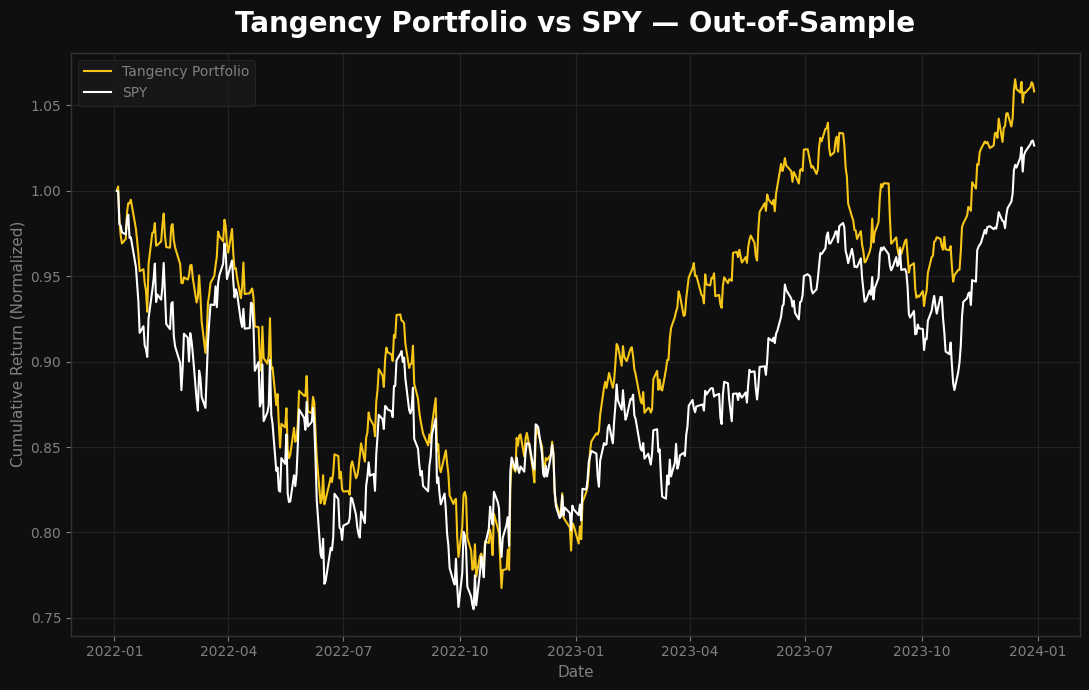

In [125]:
#comparing portfolio returns on test data with spy returns in the same period:

# isolate test period
test_start = '2022-01-01'
portfolio_test = stress_test_return_path[test_start:]

# spy return path over same period
spy_weights = np.array([1.0 if c == 'SPY' else 0.0 for c in data.columns])
spy_return_path = pd.Series(calculate_return_path(spy_weights, data), index=data.index)
spy_test = spy_return_path[test_start:]

# normalize both to start at 1 on the first day of test period
portfolio_test = portfolio_test / portfolio_test.iloc[0]
spy_test = spy_test / spy_test.iloc[0]

# plot
fig, ax = plt.subplots(figsize=(11, 7))
fig.patch.set_facecolor('#0f0f0f')
ax.set_facecolor('#0f0f0f')

ax.plot(portfolio_test.index, portfolio_test.values, color='#f5c518', linewidth=1.5, label='Tangency Portfolio')
ax.plot(spy_test.index, spy_test.values, color='white', linewidth=1.5, label='SPY')

ax.set_xlabel('Date', color='grey', fontsize=11)
ax.set_ylabel('Cumulative Return (Normalized)', color='grey', fontsize=11)
ax.set_title('Tangency Portfolio vs SPY — Out-of-Sample', color='white', fontsize=20, fontweight='bold', pad=15)
ax.tick_params(colors='grey')
for spine in ax.spines.values():
    spine.set_edgecolor('#333333')
ax.grid(True, color='#222222', linewidth=0.8)
ax.legend(facecolor='#1a1a1a', edgecolor='#333333', labelcolor='grey', fontsize=10)

plt.tight_layout()
plt.show()

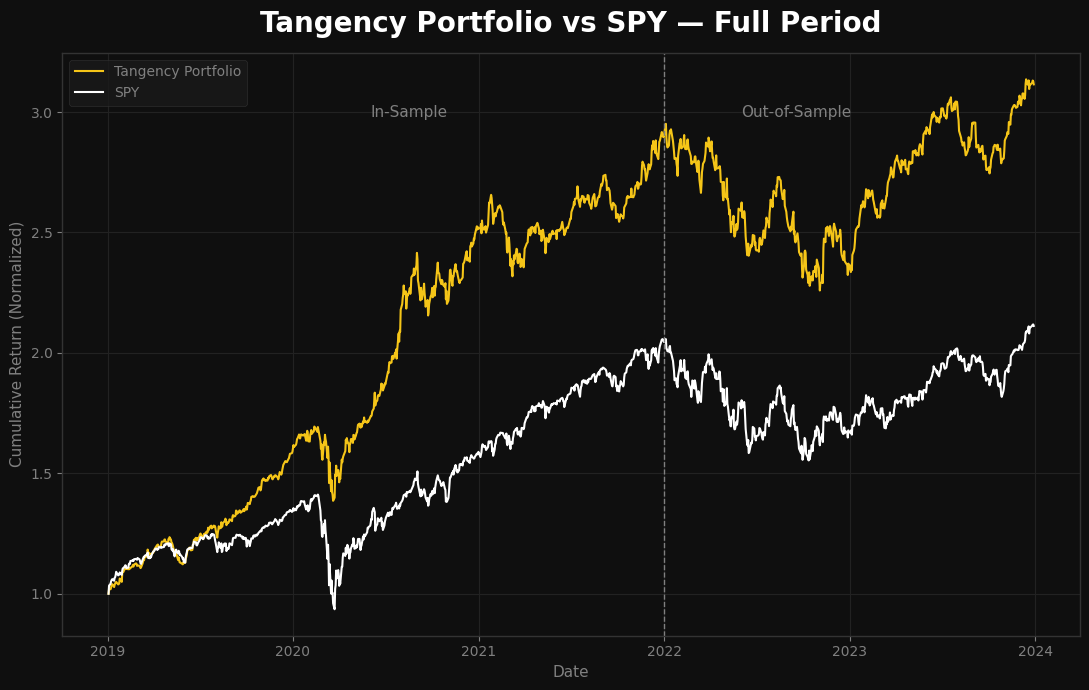

In [119]:
# normalize both to start at 1 on the first day
portfolio_full = stress_test_return_path.dropna() / stress_test_return_path.dropna().iloc[0]
spy_full = spy_return_path.dropna() / spy_return_path.dropna().iloc[0]

fig, ax = plt.subplots(figsize=(11, 7))
fig.patch.set_facecolor('#0f0f0f')
ax.set_facecolor('#0f0f0f')

ax.plot(portfolio_full.index, portfolio_full.values, color='#f5c518', linewidth=1.5, label='Tangency Portfolio')
ax.plot(spy_full.index, spy_full.values, color='white', linewidth=1.5, label='SPY')

# train/test split line
ax.axvline(x=pd.Timestamp('2022-01-01'), color='grey', linewidth=1, linestyle='--')
ax.text(pd.Timestamp('2020-06-01'), portfolio_full.max() * 0.95, 'In-Sample', color='grey', fontsize=11)
ax.text(pd.Timestamp('2022-06-01'), portfolio_full.max() * 0.95, 'Out-of-Sample', color='grey', fontsize=11)

ax.set_xlabel('Date', color='grey', fontsize=11)
ax.set_ylabel('Cumulative Return (Normalized)', color='grey', fontsize=11)
ax.set_title('Tangency Portfolio vs SPY — Full Period', color='white', fontsize=20, fontweight='bold', pad=15)
ax.tick_params(colors='grey')
for spine in ax.spines.values():
    spine.set_edgecolor('#333333')
ax.grid(True, color='#222222', linewidth=0.8)
ax.legend(facecolor='#1a1a1a', edgecolor='#333333', labelcolor='grey', fontsize=10)

plt.tight_layout()
plt.show()

In [120]:
# conclusion: the dominance of the optimal portfolio over the
# benchmark SPY basically vanished in the out-of-sample period, suggesting overfitting.

In [121]:
#the poorer performance in the test period could be due to a broader worse period in the market however.
# for an accurate assesment, we must compare to an equal weight portfolio baseline.


In [122]:
stress_test_return_path

Date
2019-01-02         NaN
2019-01-03    0.952431
2019-01-04    0.969380
2019-01-07    0.970373
2019-01-08    0.975843
                ...   
2023-12-22    2.964509
2023-12-26    2.973770
2023-12-27    2.981865
2023-12-28    2.978898
2023-12-29    2.966723
Length: 1258, dtype: float64

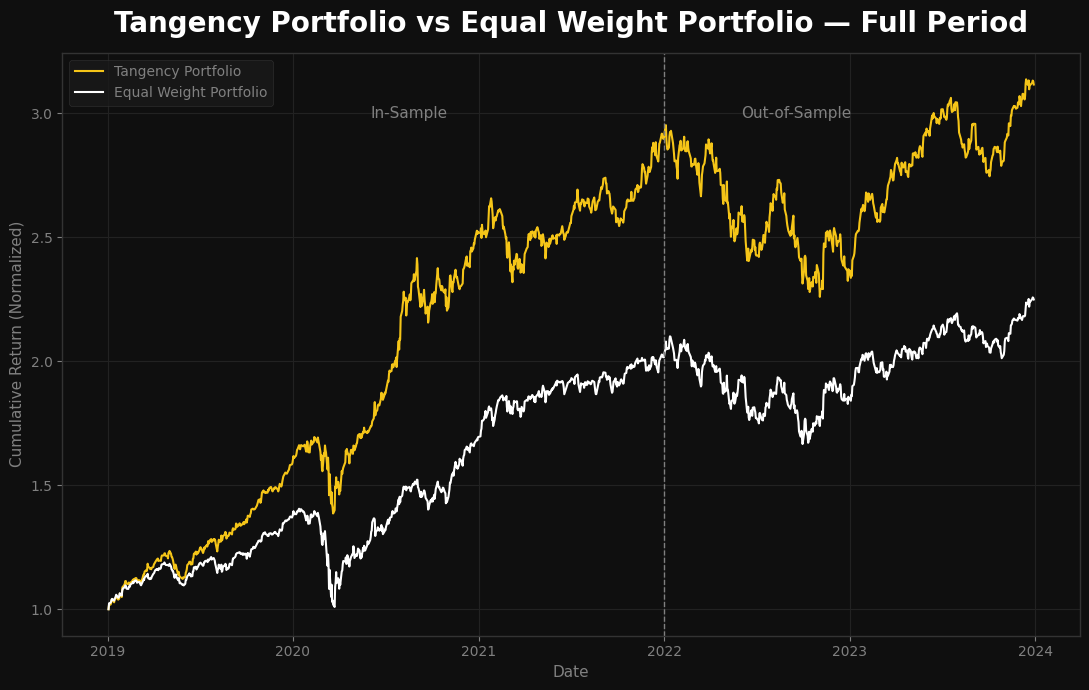

In [123]:
# normalize both to start at 1 on the first day
portfolio_full = stress_test_return_path.dropna() / stress_test_return_path.dropna().iloc[0]
eq_return_path = pd.Series(eq_return_path, stress_test_return_path.index)
eq_full = eq_return_path.dropna() / eq_return_path.dropna().iloc[0]

fig, ax = plt.subplots(figsize=(11, 7))
fig.patch.set_facecolor('#0f0f0f')
ax.set_facecolor('#0f0f0f')

ax.plot(portfolio_full.index, portfolio_full.values, color='#f5c518', linewidth=1.5, label='Tangency Portfolio')
ax.plot(eq_full.index, eq_full.values, color='white', linewidth=1.5, label='Equal Weight Portfolio')

# train/test split line
ax.axvline(x=pd.Timestamp('2022-01-01'), color='grey', linewidth=1, linestyle='--')
ax.text(pd.Timestamp('2020-06-01'), portfolio_full.max() * 0.95, 'In-Sample', color='grey', fontsize=11)
ax.text(pd.Timestamp('2022-06-01'), portfolio_full.max() * 0.95, 'Out-of-Sample', color='grey', fontsize=11)

ax.set_xlabel('Date', color='grey', fontsize=11)
ax.set_ylabel('Cumulative Return (Normalized)', color='grey', fontsize=11)
ax.set_title('Tangency Portfolio vs Equal Weight Portfolio — Full Period', color='white', fontsize=20, fontweight='bold', pad=15)
ax.tick_params(colors='grey')
for spine in ax.spines.values():
    spine.set_edgecolor('#333333')
ax.grid(True, color='#222222', linewidth=0.8)
ax.legend(facecolor='#1a1a1a', edgecolor='#333333', labelcolor='grey', fontsize=10)

plt.tight_layout()
plt.show()

In [124]:
#calculating out of sample return of both:
oos_start = '2022-01-01'

portfolio_oos = portfolio_full[portfolio_full.index >= oos_start]
eq_oos = eq_full[eq_full.index >= oos_start]

tangency_total_return = (portfolio_oos.iloc[-1] / portfolio_oos.iloc[0] - 1) * 100
eq_total_return = (eq_oos.iloc[-1] / eq_oos.iloc[0] - 1) * 100

print(f"Tangency Portfolio OOS Total Return: {tangency_total_return:.2f}%")
print(f"Equal Weight Portfolio OOS Total Return: {eq_total_return:.2f}%")

Tangency Portfolio OOS Total Return: 5.82%
Equal Weight Portfolio OOS Total Return: 9.54%


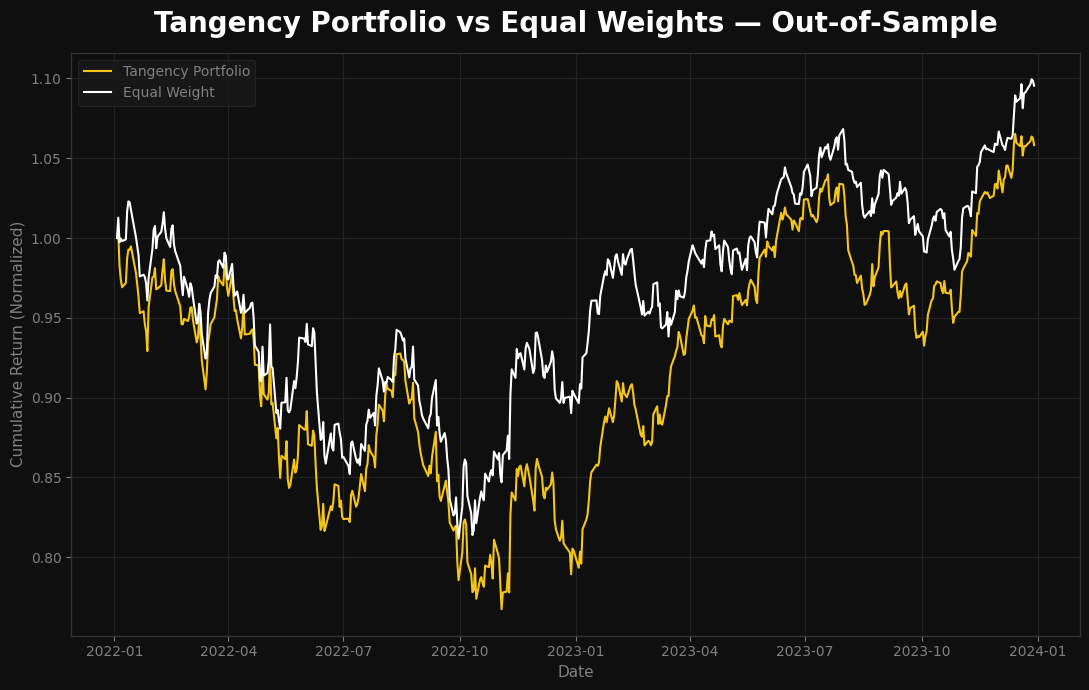

In [126]:
#comparing portfolio returns on test data with spy returns in the same period:

# isolate test period
test_start = '2022-01-01'
portfolio_test = stress_test_return_path[test_start:]

# spy return path over same period
equal_weights = np.ones(len(data.columns)) / len(data.columns)
eq_return_path = pd.Series(calculate_return_path(equal_weights, data), index=data.index)
eq_test = eq_return_path[test_start:]

# normalize both to start at 1 on the first day of test period
portfolio_test = portfolio_test / portfolio_test.iloc[0]
eq_test = eq_test / eq_test.iloc[0]

# plot
fig, ax = plt.subplots(figsize=(11, 7))
fig.patch.set_facecolor('#0f0f0f')
ax.set_facecolor('#0f0f0f')

ax.plot(portfolio_test.index, portfolio_test.values, color='#f5c518', linewidth=1.5, label='Tangency Portfolio')
ax.plot(eq_test.index, eq_test.values, color='white', linewidth=1.5, label='Equal Weight')

ax.set_xlabel('Date', color='grey', fontsize=11)
ax.set_ylabel('Cumulative Return (Normalized)', color='grey', fontsize=11)
ax.set_title('Tangency Portfolio vs Equal Weights — Out-of-Sample', color='white', fontsize=20, fontweight='bold', pad=15)
ax.tick_params(colors='grey')
for spine in ax.spines.values():
    spine.set_edgecolor('#333333')
ax.grid(True, color='#222222', linewidth=0.8)
ax.legend(facecolor='#1a1a1a', edgecolor='#333333', labelcolor='grey', fontsize=10)

plt.tight_layout()
plt.show()